# Visualize new runs (defaults and optimals)

In [1]:
import os
import json
import math
import pandas as pd
import numpy as np
import xarray as xr
import sklearn
import glob
import pickle
from esem import gp_model
from esem.utils import get_random_params, plot_results, prettify_plot, add_121_line, leave_one_out
import iris
import iris.quickplot as qplt
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.metrics import make_scorer, r2_score
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_absolute_error as mae
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline

#import gpflow
#import tensorflow as tf
import importlib.util
from datetime import date
from datetime import datetime
import timeit
from timeit import default_timer as timer

from concurrent.futures import ThreadPoolExecutor

from mpl_toolkits.mplot3d import Axes3D
#from scipy.optimize import basinhopping
#from scipy.optimize import minimize
import csv
#address warning messages: pip install tensorflow[and-cuda]

2026-04-30 23:27:56.067068: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-30 23:27:56.067118: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-30 23:27:56.185922: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-30 23:27:56.284936: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/global/homes/j/jpaige3/.conda/env

In [2]:
DY1_obs_dir = '/global/cfs/cdirs/e3smdata/simulations/ecp-autotune/obs/'
DY1_precip_obs_file = DY1_obs_dir + 'IMERG.precip_total_surf_mass_flux.daily_AVERAGE.ne30pg2.20160807_mahf708.nc' #maybe check this
DY1_LW_obs_file = DY1_obs_dir + 'CERES.LW_flux_up_at_model_top.daily_AVERAGE.ne30pg2.20160807_mahf708.nc'
#DY1_SW_dn_obs_file = DY1_obs_dir + 'CERES.SW_flux_dn_at_model_top.daily_AVERAGE.ne30pg2.20160807_mahf708.nc'
DY1_SW_up_obs_file = DY1_obs_dir + 'CERES.SW_flux_up_at_model_top.daily_AVERAGE.ne30pg2.20160807_mahf708.nc'
DY1_LWP_file = DY1_obs_dir + 'mac.clwp-tlwp-wvp.20160807.ne30pg2.nc'

DY1_PCP_obs = xr.open_dataset(DY1_precip_obs_file).variables['precip_total_surf_mass_flux'].squeeze('time')
DY1_TLWP_obs = (xr.open_dataset(DY1_LWP_file).variables['tlwp']*1e-3).squeeze('time')
DY1_OSR_obs = xr.open_dataset(DY1_SW_up_obs_file).variables['SW_flux_up_at_model_top'].squeeze('time')
DY1_OLR_obs = xr.open_dataset(DY1_LW_obs_file).variables['LW_flux_up_at_model_top'].squeeze('time')

In [3]:
DY2_obs_dir = '/global/cfs/projectdirs/e3smdata/simulations/SCREAM.2024-autocal-00.ne1024pg2/obs/'
DY2_precip_obs_file = DY2_obs_dir + 'IMERG.precip_total_surf_mass_flux.AVERAGE.ne30pg2.20200126.nc'
DY2_LW_obs_file = DY2_obs_dir + 'CERES.LW_flux_up_at_model_top.AVERAGE.ne30pg2.20200126.nc'
#DY2_SW_dn_obs_file = DY2_obs_dir + 'CERES.SW_flux_dn_at_model_top.AVERAGE.ne30pg2.20200126.nc'
DY2_SW_up_obs_file = DY2_obs_dir + 'CERES.SW_flux_up_at_model_top.AVERAGE.ne30pg2.20200126.nc'
DY2_LWP_file = DY2_obs_dir + 'mac.clwp-tlwp-wvp.20200126.ne30pg2.nc'

DY2_PCP_obs = xr.open_dataset(DY2_precip_obs_file).variables['precip_total_surf_mass_flux'].squeeze('time')
DY2_TLWP_obs = (xr.open_dataset(DY2_LWP_file).variables['tlwp']*1e-3).squeeze('time')
DY2_OSR_obs = xr.open_dataset(DY2_SW_up_obs_file).variables['SW_flux_up_at_model_top'].squeeze('time')
DY2_OLR_obs = xr.open_dataset(DY2_LW_obs_file).variables['LW_flux_up_at_model_top'].squeeze('time')

## Restarting from saved model/data

Load in regions and define zones to take geographical averages

In [4]:
regions_file = xr.open_dataset('/global/cfs/projectdirs/e3smdata/simulations/ecp-autotune/regions.nc')
regions_list = ['poles','extratropical_land','extratropical_ocean','tropical_land','ascending_tropical_ocean','descending_tropical_ocean']
#area = ppe_dataset.area[1,:] #only taking the first row, because all rows should have the same values
control = xr.open_dataset('/global/cfs/projectdirs/e3smdata/simulations/ecp-autotune/SCREAM.2024-autocal-00.ne1024pg2/m0000/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc')
area = control.variables['area'][:]
lat = control.variables['lat'][:]
lon = control.variables['lon'][:]

In [5]:
def zonal_means_native(data, area, lat, lon):
    data = data.squeeze()
    masked_area = np.where(np.isnan(data), np.nan, area).squeeze()
    lat = lat.squeeze()
    lat_bands = np.linspace(-90, 90, 19) #currently dividing globe in 18 zones via 19 borders - 10 degree bands
    zonal_means = dict()
    for i in range(len(lat_bands) - 1):
        mask_zone = (lat >= lat_bands[i]) & (lat < lat_bands[i+1]) #includes lower bound in the band (! might cause missing north pole)
        data_zone = np.where(mask_zone, data, np.nan)
        area_zone = np.where(mask_zone, masked_area, np.nan)
        zone_center = lat_bands[i] + (lat_bands[i+1] - lat_bands[i])/2
        if np.all(np.isnan(data_zone)) or np.nansum(area_zone) == 0:
            zonal_means[zone_center] = np.nan
        else:
            zone_mean = np.nansum(data_zone * area_zone) / np.nansum(area_zone)
            zonal_means[zone_center] = zone_mean
    return zonal_means

def regional_means_native(data, area, region_data):  
    #region_data = xr.open_dataset('/global/cfs/projectdirs/e3smdata/simulations/ecp-autotune/regions.nc') #for performance improvement move region_data out as argument
    data = data.squeeze()
    masked_area = np.where(np.isnan(data), np.nan, area).squeeze()
    regions_list = ['poles', 'extratropical_land', 'extratropical_ocean', 
                    'tropical_land', 'ascending_tropical_ocean', 'descending_tropical_ocean']
    region_means = dict()
    for reg_name in regions_list:
        mask_reg = region_data[reg_name].squeeze()
        data_reg = np.where(mask_reg > 0, data, np.nan)
        area_reg = np.where(mask_reg > 0, masked_area, np.nan)
        if np.all(np.isnan(data_reg)) or np.nansum(area_reg) == 0:
            region_means[reg_name] = np.nan
        else:
            reg_mean = np.nansum(data_reg * area_reg) / np.nansum(area_reg)
            region_means[reg_name] = reg_mean
    return region_means

def global_means_native(data, area): #takes global averages
    data = data.squeeze()
    masked_area = np.where(np.isnan(data), np.nan, area).squeeze()
    global_mean = np.nansum(data*masked_area)/np.nansum(masked_area)
    return global_mean

In [6]:
#load back observations
obs_filename = '/global/cfs/cdirs/e3sm/jpaige3/ESEm/GP_Saved_Model_Data/obs_2026-03-23_12-24-55.pkl'

with open(obs_filename, 'rb') as f:
    loaded_obs = pickle.load(f)
    
zrg_obs = loaded_obs['zrg_obs']
PCP_zrg_obs = loaded_obs['PCP_zrg_obs']
TLWP_zrg_obs = loaded_obs['TLWP_zrg_obs']
OSR_zrg_obs = loaded_obs['OSR_zrg_obs']
OLR_zrg_obs = loaded_obs['OLR_zrg_obs']
n_cols_per_df = zrg_obs.shape[1] // 4 #50 DY1 and DY2

In [7]:
# Load back GP proj
#GP_proj_filename = "/global/cfs/cdirs/e3sm/jpaige3/ESEm/GP_Saved_Model_Data/CORRECT_GP_ZRG_masked_proj_2026-03-04_11-36-39.pkl" #has masks properly and norms to full parameter ranges
#GP_proj_filename = '/global/cfs/cdirs/e3sm/jpaige3/ESEm/GP_Saved_Model_Data/GP_ZRG_masked_proj_2026-03-07_13-47-39.pkl'
#GP_proj_filename = '/global/cfs/cdirs/e3sm/jpaige3/ESEm/GP_Saved_Model_Data/GP_ZRG_masked_proj_2026-03-23_09-47-06_removedzone.pkl'
GP_proj_filename = '/global/cfs/cdirs/e3sm/jpaige3/ESEm/GP_Saved_Model_Data/GP_ZRG_masked_proj_2026-03-23_12-24-55.pkl'

with open(GP_proj_filename, 'rb') as f:
    loaded = pickle.load(f)

# Access data
train_run_labels = loaded['X_train_index']
X_pipe_sk_minmax = loaded['X_pipeline']
Y_pipe_sk_ss_PCP = loaded['Y_pipeline_PCP']
Y_pipe_sk_ss_TLWP = loaded['Y_pipeline_TLWP']
Y_pipe_sk_ss_OSR = loaded['Y_pipeline_OSR']
Y_pipe_sk_ss_OLR = loaded['Y_pipeline_OLR']
### normalized/transformed
X_train_norm = loaded['X_train_norm']
Y_train_norm = loaded['Y_train_norm']
PCP_train_norm = loaded['PCP_train_norm']
TLWP_train_norm = loaded['TLWP_train_norm']
OSR_train_norm = loaded['OSR_train_norm']
OLR_train_norm = loaded['OLR_train_norm']
### unnormalized/untransformed
X_train = loaded['X_train']
Y_train_ZRG = loaded['Y_train']
PCP_train = loaded['PCP_train']
TLWP_train = loaded['TLWP_train']
OSR_train = loaded['OSR_train']
OLR_train = loaded['OLR_train']

The observational dataset and the training dataset (the full ppe in this case) have been loaded in. They are composed of DY1 and DY2 data with zonal, regional, and global data. They are separated by target variable so (for independent normalization).

In [8]:
print(X_train_norm.shape, Y_train_norm.shape)

(153, 16) (153, 44, 4)


In [9]:
areas_to_remove = ['DY1_85.0', 'DY1_-85.0', 'DY1_-75.0', 'DY2_85.0', 'DY2_-85.0', 'DY2_-75.0']

In [10]:
PCP_obs_norm = Y_pipe_sk_ss_PCP.transform(PCP_zrg_obs)
TLWP_obs_norm = Y_pipe_sk_ss_TLWP.transform(TLWP_zrg_obs)
OSR_obs_norm = Y_pipe_sk_ss_OSR.transform(OSR_zrg_obs)
OLR_obs_norm = Y_pipe_sk_ss_OLR.transform(OLR_zrg_obs)

obs_norm = np.stack([PCP_obs_norm, TLWP_obs_norm, OSR_obs_norm, OLR_obs_norm])
obs_norm = obs_norm.transpose(1, 2, 0)

obs_untransform = np.stack([PCP_zrg_obs, TLWP_zrg_obs, OSR_zrg_obs, OLR_zrg_obs])
obs_untransform = obs_untransform.transpose(1, 2, 0)
obs_untransform.shape

(1, 44, 4)

## Training the model

In [11]:
print(X_train_norm.shape, Y_train_norm.shape) #the first dimension of these must match

(153, 16) (153, 44, 4)


In [12]:
model_gp = gp_model(X_train_norm, Y_train_norm) #creates the model form, but is not trained yet
#this default kernel has been useful (combination of linear, polynomial, and RBF) and outperformed other options individually

2026-04-30 23:28:19.615712: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8517 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:c3:00.0, compute capability: 8.0


In [13]:
model_gp.train() #training the model--should take only a few seconds with the current data size, could be improved with GPU usage

2026-04-30 23:28:24.343136: I tensorflow/core/util/cuda_solvers.cc:178] Creating GpuSolver handles for stream 0x55ae62132ea0


## Optimizing

##### All mostly on the same range -- should help with optimizing

In [14]:
np.min(PCP_train_norm), np.max(PCP_train_norm)

(-3.8935642, 7.998905)

In [15]:
np.min(TLWP_train_norm), np.max(TLWP_train_norm)

(-3.2713733, 5.6672254)

In [16]:
np.min(OSR_train_norm), np.max(OSR_train_norm)

(-3.2430043, 8.166547)

In [17]:
np.min(OLR_train_norm), np.max(OLR_train_norm)

(-10.43731, 3.036268)

### Cost function - weights on regions and variables

In [25]:
cost_function_path =  f"/global/cfs/cdirs/e3sm/jpaige3/optimizing/cost_functions/default_cost_fun.py"
spec = importlib.util.spec_from_file_location("cost_function", cost_function_path)
cost_function = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cost_function)

In [26]:
#variable weighting
var_weights_dict = cost_function.var_weights_dict
#zonal, regional, global weighting
zrg_weights_dict = cost_function.zrg_weights_dict
#summer/winter weights
DY_weights_dict = cost_function.DY_weights_dict
#zonal weights for weighted combination
zonal_weights = cost_function.zonal_weights
#regional weights for weighted combination
regional_weights = cost_function.regional_weights

In [27]:
lat_bands = np.linspace(-90,90,19) 

In [28]:
lat_bands_full = np.linspace(-90,90,19) 
lat_bands = np.delete(lat_bands_full, [0, 1, -1])
lat_bands

array([-70., -60., -50., -40., -30., -20., -10.,   0.,  10.,  20.,  30.,
        40.,  50.,  60.,  70.,  80.])

In [29]:
lamlow_index = X_train.columns.get_loc('lambda_low')
lamhigh_index = X_train.columns.get_loc('lambda_high')

In [30]:
def params_to_cost(params_guess):
    violation = params_guess[lamlow_index] - params_guess[lamhigh_index]
    if violation > 0:
        return 1e2 + 1e2 * violation
    m_gp_guess, v_gp_guess = model_gp.predict(params_guess.reshape(1, -1))
    cost = ZRG_cost_function_mae_weighted(m_gp_guess, obs_norm, var_weights_dict, DY_weights_dict, zrg_weights_dict, zonal_weights, regional_weights)
    #return float(cost)
    return cost

def params_to_cost_print(params_guess): #, obs, area_weights, var_weights_dict, zrg_weights_dict):
    #if params_guess[6] > params_guess[7]:
    violation = params_guess[lamlow_index] - params_guess[lamhigh_index] # lambda_low - lambda_high
    if violation > 0:
        return 1e2 + 1e2 * violation  # linear penalty: gets worse the more you violate
    m_gp_guess, v_gp_guess = model_gp.predict(params_guess.reshape(1, -1))
    cost = ZRG_cost_function_mae_weighted_print(m_gp_guess, obs_norm, var_weights_dict, DY_weights_dict, zrg_weights_dict, zonal_weights, regional_weights)
    return cost

In [31]:
def ZRG_cost_function_mae_weighted(preds, obs, var_weights_dict, DY_weights_dict, zrg_weights_dict, zonal_weights = None, regional_weights = None): #area_weights,  
    preds = preds.squeeze()
    obs = obs.squeeze()
    
    PCP_proj_c = preds[:,0] #this is a numpy array
    TLWP_proj_c = preds[:,1]
    OSR_proj_c = preds[:,2]
    OLR_proj_c = preds[:,3]
    
    PCP_obs_c = obs[:,0] #this is a numpy array
    TLWP_obs_c = obs[:,1]
    OSR_obs_c = obs[:,2]
    OLR_obs_c = obs[:,3]
    
    z_num = len(lat_bands)-1
    r_num = len(regions_list)
    all_num = z_num + r_num + 1

    DY1_zonal_cost = zrg_weights_dict['zonal']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[0:z_num], PCP_proj_c[0:z_num], sample_weight=zonal_weights),                            
                                                   var_weights_dict['TLWP']*mae(TLWP_obs_c[0:z_num], TLWP_proj_c[0:z_num], sample_weight=zonal_weights),
                                                   var_weights_dict['OSR']*mae(OSR_obs_c[0:z_num], OSR_proj_c[0:z_num], sample_weight=zonal_weights),
                                                   var_weights_dict['OLR']*mae(OLR_obs_c[0:z_num], OLR_proj_c[0:z_num], sample_weight=zonal_weights)])
    DY2_zonal_cost = zrg_weights_dict['zonal']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[(all_num):(all_num+z_num)], PCP_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['TLWP']*mae(TLWP_obs_c[(all_num):(all_num+z_num)], TLWP_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['OSR']*mae(OSR_obs_c[(all_num):(all_num+z_num)], OSR_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['OLR']*mae(OLR_obs_c[(all_num):(all_num+z_num)], OLR_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights)])
    
    DY1_regional_cost = zrg_weights_dict['regional']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[(z_num):(z_num+r_num)], PCP_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['TLWP']*mae(TLWP_obs_c[(z_num):(z_num+r_num)], TLWP_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OSR']*mae(OSR_obs_c[(z_num):(z_num+r_num)], OSR_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OLR']*mae(OLR_obs_c[(z_num):(z_num+r_num)], OLR_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights)])
    DY2_regional_cost = zrg_weights_dict['regional']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[(all_num+z_num):(all_num+z_num+r_num)], PCP_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['TLWP']*mae(TLWP_obs_c[(all_num+z_num):(all_num+z_num+r_num)], TLWP_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OSR']*mae(OSR_obs_c[(all_num+z_num):(all_num+z_num+r_num)], OSR_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OLR']*mae(OLR_obs_c[(all_num+z_num):(all_num+z_num+r_num)], OLR_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights)])
    
    DY1_global_cost = zrg_weights_dict['global']*np.sum([var_weights_dict['PCP']*abs(PCP_obs_c[all_num-1] - PCP_proj_c[all_num-1]),
                                                     var_weights_dict['TLWP']*abs(TLWP_obs_c[all_num-1] - TLWP_proj_c[all_num-1]),
                                                     var_weights_dict['OSR']*abs(OSR_obs_c[all_num-1] - OSR_proj_c[all_num-1]),
                                                     var_weights_dict['OLR']*abs(OLR_obs_c[all_num-1] - OLR_proj_c[all_num-1])])
    DY2_global_cost = zrg_weights_dict['global']*np.sum([var_weights_dict['PCP']*abs(PCP_obs_c[-1] - PCP_proj_c[-1]),
                                                     var_weights_dict['TLWP']*abs(TLWP_obs_c[-1] - TLWP_proj_c[-1]),
                                                     var_weights_dict['OSR']*abs(OSR_obs_c[-1] - OSR_proj_c[-1]),
                                                     var_weights_dict['OLR']*abs(OLR_obs_c[-1] - OLR_proj_c[-1])])

    cost = DY_weights_dict['DY1']*(DY1_zonal_cost + DY1_regional_cost + DY1_global_cost) + DY_weights_dict['DY2']*(DY2_zonal_cost + DY2_regional_cost + DY2_global_cost)
    
    return cost

In [32]:
def ZRG_cost_function_mae_weighted_print(preds, obs, var_weights_dict, DY_weights_dict, zrg_weights_dict, zonal_weights = None, regional_weights = None): #area_weights,  
    preds = preds.squeeze()
    obs = obs.squeeze()
    
    PCP_proj_c = preds[:,0] #this is a numpy array
    TLWP_proj_c = preds[:,1]
    OSR_proj_c = preds[:,2]
    OLR_proj_c = preds[:,3]
    
    PCP_obs_c = obs[:,0] #this is a numpy array
    TLWP_obs_c = obs[:,1]
    OSR_obs_c = obs[:,2]
    OLR_obs_c = obs[:,3]
    
    z_num = len(lat_bands)-1
    r_num = len(regions_list)
    all_num = z_num + r_num + 1

    DY1_zonal_cost = zrg_weights_dict['zonal']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[0:z_num], PCP_proj_c[0:z_num], sample_weight=zonal_weights),                            
                                                   var_weights_dict['TLWP']*mae(TLWP_obs_c[0:z_num], TLWP_proj_c[0:z_num], sample_weight=zonal_weights),
                                                   var_weights_dict['OSR']*mae(OSR_obs_c[0:z_num], OSR_proj_c[0:z_num], sample_weight=zonal_weights),
                                                   var_weights_dict['OLR']*mae(OLR_obs_c[0:z_num], OLR_proj_c[0:z_num], sample_weight=zonal_weights)])
    DY2_zonal_cost = zrg_weights_dict['zonal']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[(all_num):(all_num+z_num)], PCP_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['TLWP']*mae(TLWP_obs_c[(all_num):(all_num+z_num)], TLWP_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['OSR']*mae(OSR_obs_c[(all_num):(all_num+z_num)], OSR_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights),
                                                   var_weights_dict['OLR']*mae(OLR_obs_c[(all_num):(all_num+z_num)], OLR_proj_c[(all_num):(all_num+z_num)], sample_weight=zonal_weights)])
    
    DY1_regional_cost = zrg_weights_dict['regional']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[(z_num):(z_num+r_num)], PCP_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['TLWP']*mae(TLWP_obs_c[(z_num):(z_num+r_num)], TLWP_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OSR']*mae(OSR_obs_c[(z_num):(z_num+r_num)], OSR_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OLR']*mae(OLR_obs_c[(z_num):(z_num+r_num)], OLR_proj_c[(z_num):(z_num+r_num)], sample_weight=regional_weights)])
    DY2_regional_cost = zrg_weights_dict['regional']*np.sum([var_weights_dict['PCP']*mae(PCP_obs_c[(all_num+z_num):(all_num+z_num+r_num)], PCP_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['TLWP']*mae(TLWP_obs_c[(all_num+z_num):(all_num+z_num+r_num)], TLWP_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OSR']*mae(OSR_obs_c[(all_num+z_num):(all_num+z_num+r_num)], OSR_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights),
                                                         var_weights_dict['OLR']*mae(OLR_obs_c[(all_num+z_num):(all_num+z_num+r_num)], OLR_proj_c[(all_num+z_num):(all_num+z_num+r_num)], sample_weight=regional_weights)])
    
    DY1_global_cost = zrg_weights_dict['global']*np.sum([var_weights_dict['PCP']*abs(PCP_obs_c[all_num-1] - PCP_proj_c[all_num-1]),
                                                     var_weights_dict['TLWP']*abs(TLWP_obs_c[all_num-1] - TLWP_proj_c[all_num-1]),
                                                     var_weights_dict['OSR']*abs(OSR_obs_c[all_num-1] - OSR_proj_c[all_num-1]),
                                                     var_weights_dict['OLR']*abs(OLR_obs_c[all_num-1] - OLR_proj_c[all_num-1])])
    DY2_global_cost = zrg_weights_dict['global']*np.sum([var_weights_dict['PCP']*abs(PCP_obs_c[-1] - PCP_proj_c[-1]),
                                                     var_weights_dict['TLWP']*abs(TLWP_obs_c[-1] - TLWP_proj_c[-1]),
                                                     var_weights_dict['OSR']*abs(OSR_obs_c[-1] - OSR_proj_c[-1]),
                                                     var_weights_dict['OLR']*abs(OLR_obs_c[-1] - OLR_proj_c[-1])])

    #print('PCP cost', np.mean(total_PCP_cost), 'TLWP cost', np.mean(total_TLWP_cost), 'OSR cost', np.mean(total_OSR_cost), 'OLR cost', np.mean(total_OLR_cost))                       
    print('zonal_cost', (DY1_zonal_cost+DY2_zonal_cost), 'regional_cost', (DY1_regional_cost+DY2_regional_cost), 'global_cost', (DY1_global_cost+DY2_global_cost))
    print('DY1 cost', (DY1_zonal_cost + DY1_regional_cost + DY1_global_cost), 'DY2 cost', (DY2_zonal_cost + DY2_regional_cost + DY2_global_cost))

    cost = DY_weights_dict['DY1']*(DY1_zonal_cost + DY1_regional_cost + DY1_global_cost) + DY_weights_dict['DY2']*(DY2_zonal_cost + DY2_regional_cost + DY2_global_cost)
    print('cost:', cost)
    
    return cost

#### Visualizing

In [33]:
range_thl2tune = [0.1, 10]
range_qw2tune = [0.1, 10]
range_length_fac = [0.1, 10]
range_c_diag_3rd_mom = [0.1, 10]
range_Ckh = [0.1, 1]
range_Ckm = [0.1, 1]
range_lambda_low = [0.0001, 0.1]
range_lambda_high = [0.0001, 0.1]
range_spa_to_nc = [0.1, 10]
range_p3_eci = [0.1, 1]
range_p3_eri = [0.1, 1]
range_k_acc = [0.01, 100]
range_p3_dep_nucleation_exponent = [0.2, 0.304]
range_max_total_ni = [5e5, 1e7]
#range_ice_sed_knob = [0.1, 2]
range_ice_sed_knob = [1, 2]
range_p3_d_breakup_cutoff = [0, 500e-6]

dict_range_pars = dict()
dict_range_pars['length_fac'] = range_length_fac
dict_range_pars['p3_spa_to_nc'] = range_spa_to_nc
dict_range_pars['p3_k_accretion'] = range_k_acc
dict_range_pars['p3_ice_sed_knob'] = range_ice_sed_knob
dict_range_pars['thl2tune'] = range_thl2tune
dict_range_pars['qw2tune'] = range_qw2tune
dict_range_pars['c_diag_3rd_mom'] = range_c_diag_3rd_mom
dict_range_pars['Ckh'] = range_Ckh
dict_range_pars['Ckm'] = range_Ckm
dict_range_pars['lambda_low'] = range_lambda_low
dict_range_pars['lambda_high'] = range_lambda_high
dict_range_pars['p3_eci'] = range_p3_eci
dict_range_pars['p3_eri'] = range_p3_eri
dict_range_pars['p3_dep_nucleation_exponent'] = range_p3_dep_nucleation_exponent
dict_range_pars['p3_d_breakup_cutoff'] = range_p3_d_breakup_cutoff
dict_range_pars['max_total_ni'] = range_max_total_ni

In [34]:
#These should be equal
default_cost = ZRG_cost_function_mae_weighted_print(Y_train_norm[0], obs_norm, var_weights_dict, DY_weights_dict, zrg_weights_dict)
print('True default cost:', default_cost)

print('Predictions:')
pred_default_cost = params_to_cost_print(X_train_norm[0])

params_to_cost(X_train_norm[0])

zonal_cost 1.4835910846789677 regional_cost 0.8826187700033188 global_cost 0.6744296799103419
DY1 cost 1.2693412750959396 DY2 cost 1.7712982594966888
cost: 1.5203197672963142
True default cost: 1.5203197672963142
Predictions:
zonal_cost 1.4832910216499062 regional_cost 0.8824604224171597 global_cost 0.6744295507752998
DY1 cost 1.2682070763957198 DY2 cost 1.7719739184466459
cost: 1.5200904974211829


1.5200904974211829

In [35]:
sample_iter = 50
param_name_1 = 'thl2tune' 
param_name_2 = 'qw2tune'

index_1 = X_train.columns.get_loc(param_name_1)
index_2 = X_train.columns.get_loc(param_name_2)

p1_range = np.linspace(0, 1, sample_iter) #in the transformed space
p2_range = np.linspace(0, 1, sample_iter)

# Fix the other 14 parameters at the default run (already normalized)
#default_params_norm = X_train_norm[0].copy()
default_params_norm = X_pipe_sk_minmax.transform(optimal_params_final[0:-1].reshape(1, -1))[0].copy()

# Prepare grid for plotting
P1, P2 = np.meshgrid(p1_range, p2_range)
Z = np.zeros_like(P1)

# Evaluate model on the grid
for i in range(P1.shape[0]):
    for j in range(P1.shape[1]):
        params = default_params_norm.copy()
        params[index_1] = P1[i, j]  # Vary parameter 1 (already in normalized space)
        params[index_2] = P2[i, j]  # Vary parameter 2 (already in normalized space)
        Z[i,j] = params_to_cost(params)

# Plot as heatmap
plt.figure(figsize=(8, 6))
plt.contourf(P1, P2, Z, levels=50, cmap='bwr')
plt.colorbar(label='Cost')
plt.scatter(X_train_norm[0, index_1], X_train_norm[0, index_2], color='black', s=50, label='Default')
plt.xlabel(param_name_1 + ' (normalized)')
plt.ylabel(param_name_2 + ' (normalized)')
plt.title('Cost surface visualized for two parameters')
plt.legend()
plt.show()

# Or as a 3D surface plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_train_norm[0, index_1], X_train_norm[0, index_2], default_cost, color='black', s=50, label='Default')
surf = ax.plot_surface(P1, P2, Z, cmap='bwr')
fig.colorbar(surf, ax=ax, label='Cost')
ax.set_xlabel(param_name_1 + ' (normalized)')
ax.set_ylabel(param_name_2 + ' (normalized)')
ax.set_zlabel('Cost')
plt.title('3D Cost Surface Plot')
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'optimal_params_final' is not defined

### Minimizing using Basinhopping
We tried several techniques for minimizing, and are still interested in ESEm's integrated MCMC and ABC sampler. Currently, running into issues with implimenting it, possibly due to Tensorflow instillation? Several built in features to ESEm might be useful moving forward.

In [ ]:
print('all start')
start_1 = timer()

def run_bh(xstart):
    local_minimizer = {
        "method": "L-BFGS-B",
        "bounds": [(0.0, 1.0)]*16,
    }
    print('start')
    start = timer()
    result = basinhopping(
        params_to_cost,
        xstart,
        minimizer_kwargs=local_minimizer,
        niter=1
    )
    print('result', result)
    end = timer()
    print(f"time: {end - start:.4f} seconds")
    return np.hstack((result.x, result.fun))

# List of starting points
seed = 42
N_xstarts = 1
rn = np.random.RandomState(seed)
xstarts = rn.rand(N_xstarts, 16)
print(xstarts)

with ThreadPoolExecutor() as executor:
    results = list(executor.map(run_bh, xstarts))
    results = np.vstack(results)

    top10_rows = np.argsort(abs(results[:, -1]))[:10]

    # Save results
    date_str = datetime.now().strftime("%Y-%m-%d")
    csv_filename = f"/global/cfs/cdirs/e3sm/jpaige3/optimizing/Optimizing_results/results{N_xstarts}_{seed}_{date_str}.csv"
    # Save as CSV
    with open(csv_filename, "w", newline="") as f_csv:
        writer = csv.writer(f_csv)
        writer.writerow(["Rank", "param", "cost"])
        for idx, row in enumerate(top10_rows, 1):
            params = results[row][0:-1]
            cost = results[row, -1]
            print(f"Result {idx}:")
            print("  Parameters:", params)
            print("  Cost:", cost)
            writer.writerow([idx, params, cost])


end_1 = timer()
print(f"all time: {end_1 - start_1:.4f} seconds")

This is an example of a successful run with Basinhopping

In [27]:
from concurrent.futures import ThreadPoolExecutor
print('all start')
start_1 = timer()

def run_scimin(xstart):
    local_minimizer = {
        "method": "L-BFGS-B",
        "bounds": [(0.0, 1.0)]*16,
    }
    print('start')
    start = timer()
    result = basinhopping(
        params_to_cost,
        xstart,
        minimizer_kwargs=local_minimizer,
        niter=1
    )

    minimize(fun, x0, args=(), method=None, jac=None, hess=None, hessp=None, bounds=None, constraints=(), tol=None, callback=None, options=None)
    
    print('result', result)
    end = timer()
    print(f"time: {end - start:.4f} seconds")
    return np.hstack((result.x, result.fun))

# List of starting points
seed = 54
N_xstarts = 10
rn = np.random.RandomState(seed)
xstarts = rn.rand(N_xstarts, 16)
print(xstarts)

with ThreadPoolExecutor() as executor:
    results = list(executor.map(run_bh, xstarts))
    results = np.vstack(results)

    top10_rows = np.argsort(abs(results[:, -1]))[:10]

    # Save results
    date_str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    csv_filename = f"/global/cfs/cdirs/e3sm/jpaige3/optimizing/Optimizing_results/results{N_xstarts}_{seed}_{date_str}.csv"
    # Save as CSV
    with open(csv_filename, "w", newline="") as f_csv:
        writer = csv.writer(f_csv)
        writer.writerow(["Rank", "param", "cost"])
        for idx, row in enumerate(top10_rows, 1):
            params = results[row][0:-1]
            cost = results[row, -1]
            print(f"Result {idx}:")
            print("  Parameters:", params)
            print("  Cost:", cost)
            writer.writerow([idx, params, cost])


end_1 = timer()
print(f"all time: {end_1 - start_1:.4f} seconds")

# results now contains the output from each run_bh(xstart)

all start
[[0.42018297 0.3632395  0.18487669 0.51828273 0.00860545 0.96893621
  0.80138126 0.75731199 0.6714843  0.02965701 0.39156203 0.40479404
  0.18963101 0.76710564 0.61672315 0.92627396]
 [0.32512403 0.25315435 0.72021792 0.99695746 0.30787317 0.17198668
  0.17538453 0.16382659 0.58501438 0.47353556 0.46075695 0.23515401
  0.85621717 0.47089378 0.05458343 0.99325708]
 [0.19555639 0.71252488 0.81638996 0.47105727 0.26108617 0.44061904
  0.20938295 0.47290381 0.23138279 0.16117695 0.21706215 0.16071548
  0.94697523 0.62174152 0.72878496 0.87609123]
 [0.9416747  0.12094657 0.88272535 0.09609818 0.78274871 0.65746659
  0.88223916 0.6536079  0.04172773 0.63073899 0.71106128 0.45471837
  0.67166166 0.79694008 0.19569748 0.16922289]
 [0.00926992 0.75002245 0.81135434 0.04712274 0.07405571 0.80892658
  0.76134694 0.77402245 0.36689966 0.42789739 0.67152531 0.17700459
  0.60504155 0.39841353 0.82663923 0.71248988]
 [0.03735427 0.40842975 0.47169126 0.28140165 0.20171467 0.12815839
  0.219

In [27]:
to_keep = ['precip_total_surf_mass_flux','LiqWaterPath','RainWaterPath','SW_flux_up_at_model_top','LW_flux_up_at_model_top']
           
to_leave = ['SW_flux_dn','SW_flux_dn_at_model_bot','SW_flux_up','SW_flux_up_at_model_bot','SW_flux_dn_at_model_top', 'T_2m',
'T_mid', 'precip_ice_surf_mass_flux','precip_liq_surf_mass_flux','ps','qc','qi','qm','qr','qv','qv_2m','LW_flux_up','LW_flux_up_at_model_bot',
'IceWaterPath', 'LW_flux_dn','LW_flux_dn_at_model_bot','time_bnds', 'LongwaveCloudForcing', 'MeridionalVapFlux','ShortwaveCloudForcing','U','V', 
'VapWaterPath', 'ZonalVapFlux','bm','eddy_diff_mom', 'eff_radius_qc_at_cldtop','eff_radius_qi_at_cldtop', 'homme_T_mid_tend', 'homme_qv_tend',
'horiz_winds_at_model_bot', 'nc', 'ni', 'nr', 'omega', 'p3_T_mid_tend', 'p3_qv_tend', 'rrtmgp_T_mid_tend', 'sgs_buoy_flux', 'shoc_T_mid_tend',
'shoc_qv_tend', 'surf_evap', 'surf_mom_flux', 'surf_radiative_T','surf_sens_flux', 'surface_upward_latent_heat_flux', 'avg_count_ncol', 
'avg_count_ncol_lev', 'avg_count_ncol_dim', 'area', 'lat', 'lon']

## Validating Default runs

I don't know what this one is - DY2

In [45]:
new_default_data = xr.open_dataset('/global/cfs/cdirs/e3smdata/simulations/ecp-autotune/sims-dec3-2024/hh1024/m0000/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc')
    #/global/cfs/cdirs/e3smdata/simulations/ecp-autotune/sims-dec3-2024/hh1024/m0000/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc')
#new_default_data_small = new_default_data.drop_vars(to_leave)
new_default_data_small = new_default_data.get(to_keep)
new_default_data_small['TotalLiqWaterPath'] = (new_default_data_small.LiqWaterPath + new_default_data_small.RainWaterPath)
new_default_data_small.squeeze('time')

<xarray.Dataset> Size: 518kB
Dimensions:                      (ncol: 21600)
Coordinates:
    time                         object 8B 2020-01-27 00:00:00
Dimensions without coordinates: ncol
Data variables:
    precip_total_surf_mass_flux  (ncol) float32 86kB ...
    LiqWaterPath                 (ncol) float32 86kB ...
    RainWaterPath                (ncol) float32 86kB ...
    SW_flux_up_at_model_top      (ncol) float32 86kB ...
    LW_flux_up_at_model_top      (ncol) float32 86kB ...
    TotalLiqWaterPath            (ncol) float32 86kB 0.0427 0.06999 ... 0.007885
Attributes: (12/22)
    institutions:                 LLNL (Lawrence Livermore National Laborator...
    case_t0:                      2020-01-20-00000
    run_t0:                       2020-01-25-00000
    averaging_type:               AVERAGE
    averaging_frequency_units:    nhours
    averaging_frequency:          24
    ...                           ...
    contact:                      e3sm-data-support@llnl.gov
    institution_id:               E3SM-Projet
    realm:                        atmos
    history:                      created on Wed Dec 11 16:37:14 2024
    Conventions:                  CF-1.8
    product:                      model-output

New New default analysis, run on Frontier (10/9/2025) (I believe I ran this or a similar one) - DY2

In [46]:
newnew_default_data = xr.open_dataset('/global/cfs/cdirs/e3smdata/simulations/ecp-autotune/f00-dec2-2024-2444ff44ec/hh1024/m0000defle/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc')
#xr.open_dataset('/global/cfs/cdirs/e3smdata/simulations/ecp-autotune/sims-f00-dec2-2024-2444ff44ec/def-aug2019.ne1024pg2_ne1024pg2.F2010-SCREAMv1.f00-dec2-2024-2444ff44ec.2d.n2048.default/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2019-08-02-00000.nc')
#/global/cfs/cdirs/e3smdata/simulations/ecp-autotune/sims-dec3-2024/hh1024/m0000/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc')
newnew_default_data_small = newnew_default_data[to_keep]
newnew_default_data_small['TotalLiqWaterPath'] = (newnew_default_data_small.LiqWaterPath + newnew_default_data_small.RainWaterPath)
newnew_default_data_small.squeeze('time')


<xarray.Dataset> Size: 518kB
Dimensions:                      (ncol: 21600)
Coordinates:
    time                         object 8B 2020-01-27 00:00:00
Dimensions without coordinates: ncol
Data variables:
    precip_total_surf_mass_flux  (ncol) float32 86kB ...
    LiqWaterPath                 (ncol) float32 86kB ...
    RainWaterPath                (ncol) float32 86kB ...
    SW_flux_up_at_model_top      (ncol) float32 86kB ...
    LW_flux_up_at_model_top      (ncol) float32 86kB ...
    TotalLiqWaterPath            (ncol) float32 86kB 0.04707 ... 0.006498
Attributes: (12/22)
    case_t0:                      2020-01-20-00000
    run_t0:                       2020-01-25-00000
    averaging_type:               AVERAGE
    averaging_frequency_units:    nhours
    averaging_frequency:          24
    file_max_storage_type:        num_snapshots
    ...                           ...
    contact:                      e3sm-data-support@llnl.gov
    institution_id:               E3SM-Project
    realm:                        atmos
    history:                      created on Wed Oct 15 18:33:49 2025
    Conventions:                  CF-1.8
    product:                      model-output

DY2 New New New default analysis, on PM now, run by Noel (2/11/2026)

In [40]:
PM_DY2_new_default_data = xr.open_dataset('/pscratch/sd/n/ndk/e3sm_scratch/pm-gpu/p01-dec2-2024-2444ff44ec/ii1024/m0000/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc')
PM_DY2_new_default_data_small = PM_DY2_new_default_data[to_keep]
PM_DY2_new_default_data_small['TotalLiqWaterPath'] = (PM_DY2_new_default_data_small.LiqWaterPath + PM_DY2_new_default_data_small.RainWaterPath)
PM_DY2_new_default_data_small.squeeze('time')

<xarray.Dataset> Size: 518kB
Dimensions:                      (ncol: 21600)
Coordinates:
    time                         object 8B 2020-01-27 00:00:00
Dimensions without coordinates: ncol
Data variables:
    precip_total_surf_mass_flux  (ncol) float32 86kB ...
    LiqWaterPath                 (ncol) float32 86kB ...
    RainWaterPath                (ncol) float32 86kB ...
    SW_flux_up_at_model_top      (ncol) float32 86kB ...
    LW_flux_up_at_model_top      (ncol) float32 86kB ...
    TotalLiqWaterPath            (ncol) float32 86kB 0.0435 0.06697 ... 0.007551
Attributes: (12/22)
    case_t0:                      2020-01-20-00000
    run_t0:                       2020-01-25-00000
    averaging_type:               AVERAGE
    averaging_frequency_units:    nhours
    averaging_frequency:          24
    file_max_storage_type:        num_snapshots
    ...                           ...
    contact:                      e3sm-data-support@llnl.gov
    institution_id:               E3SM-Project
    realm:                        atmos
    history:                      created on Wed Feb 11 09:47:18 2026
    Conventions:                  CF-1.8
    product:                      model-output

DY1 New New New default analysis, on PM, run by Hassan (3/25/2026)

In [47]:
PM_DY1_new_default_data = xr.open_dataset('/pscratch/sd/b/beydoun/e3sm_scratch/f01-dec2-2024-2444ff44ec/hh1024/m0000defle_DY1/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2016-08-07-00000.nc')
PM_DY1_new_default_data_small = PM_DY1_new_default_data[to_keep]
PM_DY1_new_default_data_small['TotalLiqWaterPath'] = (PM_DY1_new_default_data_small.LiqWaterPath + PM_DY1_new_default_data_small.RainWaterPath)
PM_DY1_new_default_data_small.squeeze('time')

<xarray.Dataset> Size: 518kB
Dimensions:                      (ncol: 21600)
Coordinates:
    time                         object 8B 2016-08-08 00:00:00
Dimensions without coordinates: ncol
Data variables:
    precip_total_surf_mass_flux  (ncol) float32 86kB ...
    LiqWaterPath                 (ncol) float32 86kB ...
    RainWaterPath                (ncol) float32 86kB ...
    SW_flux_up_at_model_top      (ncol) float32 86kB ...
    LW_flux_up_at_model_top      (ncol) float32 86kB ...
    TotalLiqWaterPath            (ncol) float32 86kB 0.07232 0.08101 ... 0.006
Attributes: (12/22)
    case_t0:                      2016-08-01-00000
    run_t0:                       2016-08-06-00000
    averaging_type:               AVERAGE
    averaging_frequency_units:    nhours
    averaging_frequency:          24
    file_max_storage_type:        num_snapshots
    ...                           ...
    contact:                      e3sm-data-support@llnl.gov
    institution_id:               E3SM-Project
    realm:                        atmos
    history:                      created on Fri Mar 13 18:17:58 2026
    Conventions:                  CF-1.8
    product:                      model-output

In [48]:
DY1_control = xr.open_dataset('/pscratch/sd/j/jpaige3/dy1ne1024/m0000/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2016-08-07-00000.nc')

In [49]:
DY2_control = xr.open_dataset('/global/cfs/projectdirs/e3smdata/simulations/ecp-autotune/SCREAM.2024-autocal-00.ne1024pg2/m0000/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc')

Plotting functions

In [51]:
def plot_variable_comparison(datasets, control, area, lat, lon, regions_file, title, variable):
    """
    Plot zonal, regional, and global means for multiple datasets, differenced against the control.

    Parameters:
        datasets    : list of dicts with keys: 'data', 'label', 'color', 'marker'
        control     : control dataset (used as the baseline for subtraction)
        area        : area weights array
        lat         : latitude array
        lon         : longitude array
        regions_file: path to regions file
        title       : plot title prefix
        variable    : string name of the variable to extract from each dataset (e.g. 'precip_total_surf_mass_flux')
    """
    # Calculate means for control (baseline)
    control_data = getattr(control, variable)
    control_zonal    = zonal_means_native(control_data, area, lat, lon)
    control_regional = regional_means_native(control_data, area, regions_file)
    control_global   = np.array([global_means_native(control_data, area)])

    # Calculate means for all datasets
    results = []
    for dataset in datasets:
        data = getattr(dataset['data'], variable)
        result = {
            'zonal':    zonal_means_native(data, area, lat, lon),
            'regional': regional_means_native(data, area, regions_file),
            'global':   np.array([global_means_native(data, area)]),
            'label':    dataset['label'],
            'color':    dataset['color'],
            'marker':   dataset['marker']
        }
        results.append(result)

    # Build x-axis positions
    zonal_keys    = list(results[0]['zonal'].keys())
    regional_keys = list(results[0]['regional'].keys())
    array_labels  = ['global']
    z_num         = len(zonal_keys)
    r_num         = len(regional_keys)
    x_zonal       = range(z_num)
    x_regional    = range(z_num, z_num + r_num)
    x_global      = range(z_num + r_num, z_num + r_num + 1)

    # Precompute control baseline arrays
    control_zonal_values    = np.array(list(control_zonal.values()))
    control_regional_values = np.array(list(control_regional.values()))
    control_global_value    = control_global[0]

    # Create plot
    plt.figure(figsize=(8, 4))
    plt.axhline(y=0, color="black", linewidth=1, zorder=1, alpha=0.7)

    for result in results:
        zonal_values    = np.array(list(result['zonal'].values()))
        regional_values = np.array(list(result['regional'].values()))
        global_value    = result['global'][0]
        fmt             = f'-{result["marker"]}'
        color           = result['color']

        plt.plot(x_zonal,    zonal_values    - control_zonal_values,    fmt, label=result['label'], color=color)
        plt.plot(x_regional, regional_values - control_regional_values, fmt, color=color)
        plt.plot(x_global,   global_value    - control_global_value,    fmt, color=color)

    # Customize axes
    all_keys      = zonal_keys + regional_keys + array_labels
    all_positions = list(x_zonal) + list(x_regional) + list(x_global)
    plt.xticks(all_positions, all_keys, rotation=45, ha='right')
    plt.xlabel("           Center of latitude band                             Region               Global")
    plt.ylabel("Target variable error")
    plt.title(f"{title} comparison plot (to m0000)")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

### New Control visualizations

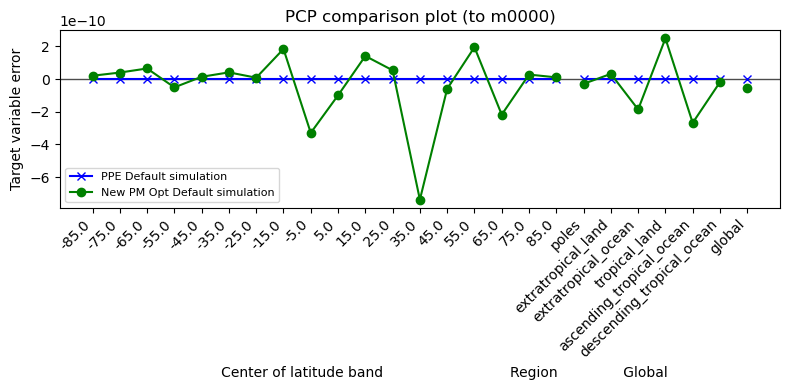

In [52]:
DY1_datasets = [
    {'data': DY1_control,  'label': 'PPE Default simulation', 'color': 'blue', 'marker': 'x'},
    {'data': PM_DY1_new_default_data,'label': 'New PM Opt Default simulation',   'color': 'green',  'marker': 'o'},
]

plot_variable_comparison(
    datasets     = DY1_datasets,
    control      = DY1_control,
    area         = area,
    lat          = lat,
    lon          = lon,
    regions_file = regions_file,
    title        = 'PCP',
    variable     = 'precip_total_surf_mass_flux'
)

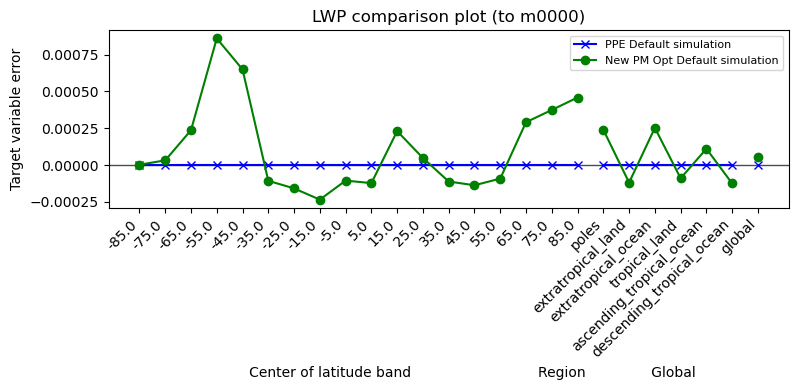

In [31]:
DY1_datasets = [
    {'data': DY1_control,  'label': 'PPE Default simulation', 'color': 'blue', 'marker': 'x'},
    {'data': PM_DY1_new_default_data,'label': 'New PM Opt Default simulation',   'color': 'green',  'marker': 'o'},
]

plot_variable_comparison(
    datasets     = DY1_datasets,
    control      = DY1_control,
    area         = area,
    lat          = lat,
    lon          = lon,
    regions_file = regions_file,
    title        = 'LWP',
    variable     = 'LiqWaterPath'
)

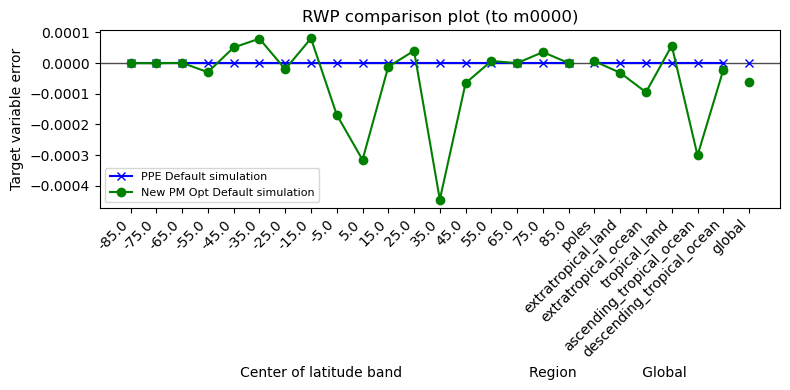

In [100]:
DY1_datasets = [
    {'data': DY1_control,  'label': 'PPE Default simulation', 'color': 'blue', 'marker': 'x'},
    {'data': DY1_newnewnew_default_data,'label': 'New PM Opt Default simulation',   'color': 'green',  'marker': 'o'},
]

plot_variable_comparison(
    datasets     = DY1_datasets,
    control      = DY1_control,
    area         = area,
    lat          = lat,
    lon          = lon,
    regions_file = regions_file,
    title        = 'RWP',
    variable     = 'RainWaterPath'
)

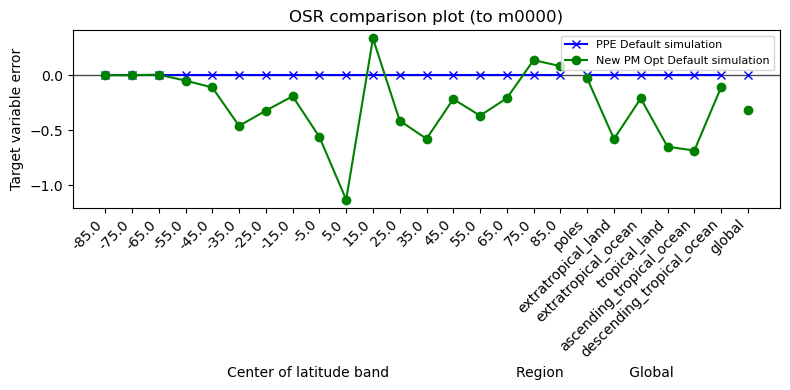

In [101]:
DY1_datasets = [
    {'data': DY1_control,  'label': 'PPE Default simulation', 'color': 'blue', 'marker': 'x'},
    {'data': DY1_newnewnew_default_data,'label': 'New PM Opt Default simulation',   'color': 'green',  'marker': 'o'},
]

plot_variable_comparison(
    datasets     = DY1_datasets,
    control      = DY1_control,
    area         = area,
    lat          = lat,
    lon          = lon,
    regions_file = regions_file,
    title        = 'OSR',
    variable     = 'SW_flux_up_at_model_top'
)

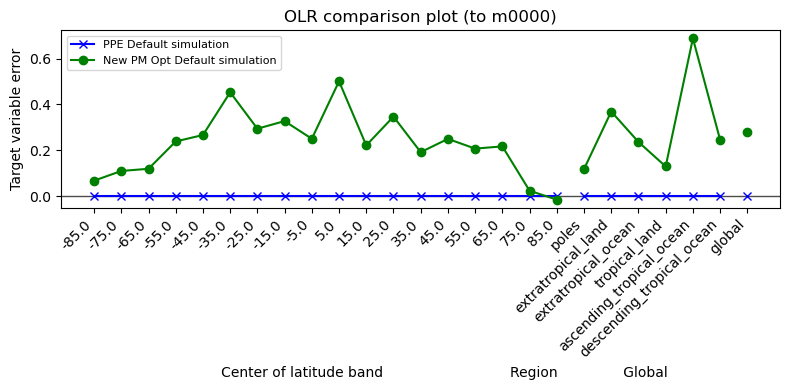

In [103]:
DY1_datasets = [
    {'data': DY1_control,  'label': 'PPE Default simulation', 'color': 'blue', 'marker': 'x'},
    {'data': DY1_newnewnew_default_data,'label': 'New PM Opt Default simulation',   'color': 'green',  'marker': 'o'},
]

plot_variable_comparison(
    datasets     = DY1_datasets,
    control      = DY1_control,
    area         = area,
    lat          = lat,
    lon          = lon,
    regions_file = regions_file,
    title        = 'OLR',
    variable     = 'LW_flux_up_at_model_top'
)

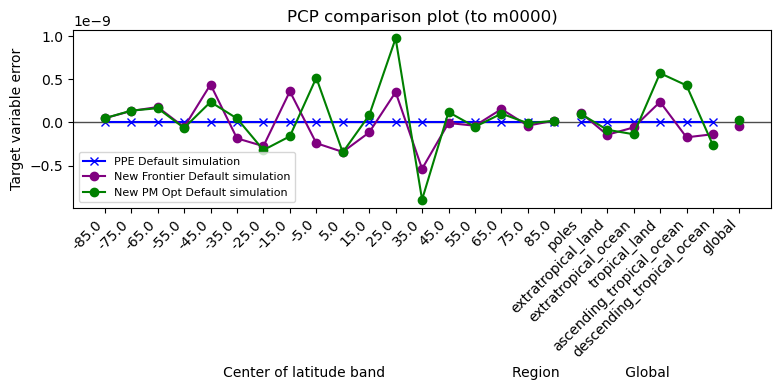

In [81]:
datasets = [
    {'data': control,  'label': 'PPE Default simulation', 'color': 'blue', 'marker': 'x'},
    {'data': newnew_default_data_small,  'label': 'New Frontier Default simulation', 'color': 'purple', 'marker': 'o'},
    {'data': newnewnew_default_data_small,'label': 'New PM Opt Default simulation',   'color': 'green',  'marker': 'o'},
]

plot_variable_comparison(
    datasets     = datasets,
    control      = control,
    area         = area,
    lat          = lat,
    lon          = lon,
    regions_file = regions_file,
    title        = 'PCP',
    variable     = 'precip_total_surf_mass_flux'
)

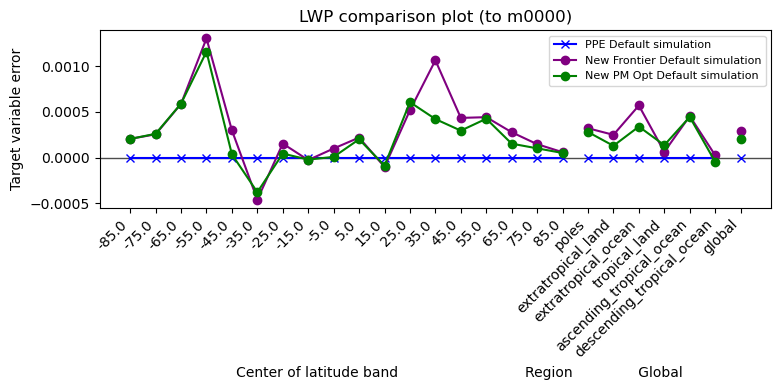

In [89]:
datasets = [
    {'data': control,  'label': 'PPE Default simulation', 'color': 'blue', 'marker': 'x'},
    {'data': newnew_default_data_small,  'label': 'New Frontier Default simulation', 'color': 'purple', 'marker': 'o'},
    {'data': newnewnew_default_data_small,'label': 'New PM Opt Default simulation',   'color': 'green',  'marker': 'o'},
]

plot_variable_comparison(
    datasets     = datasets,
    control      = control,
    area         = area,
    lat          = lat,
    lon          = lon,
    regions_file = regions_file,
    title        = 'LWP',
    variable     = 'LiqWaterPath'
)

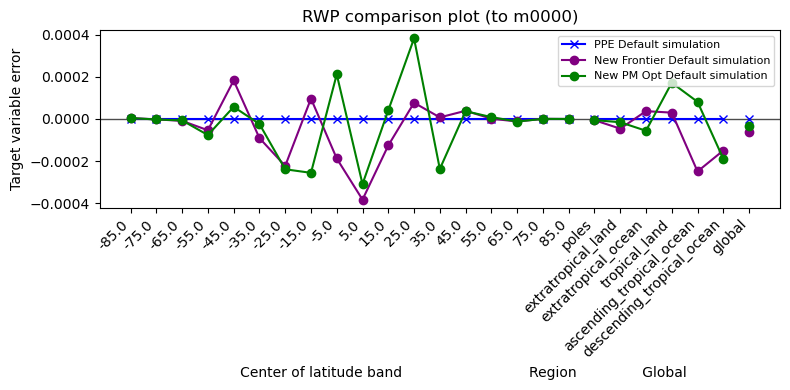

In [90]:
datasets = [
    {'data': control,  'label': 'PPE Default simulation', 'color': 'blue', 'marker': 'x'},
    {'data': newnew_default_data_small,  'label': 'New Frontier Default simulation', 'color': 'purple', 'marker': 'o'},
    {'data': newnewnew_default_data_small,'label': 'New PM Opt Default simulation',   'color': 'green',  'marker': 'o'},
]

plot_variable_comparison(
    datasets     = datasets,
    control      = control,
    area         = area,
    lat          = lat,
    lon          = lon,
    regions_file = regions_file,
    title        = 'RWP',
    variable     = 'RainWaterPath'
)

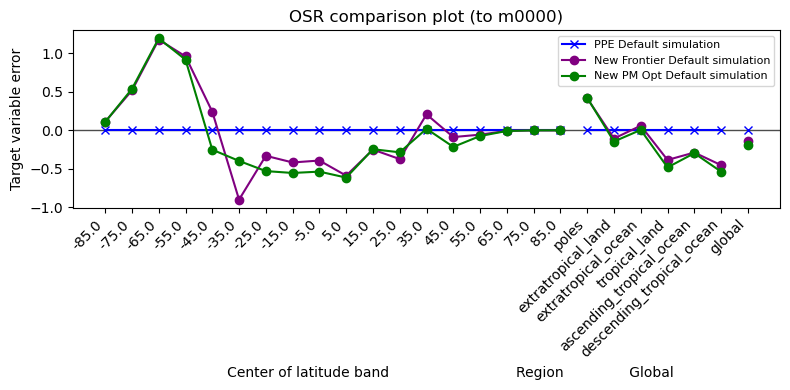

In [92]:
datasets = [
    {'data': control,  'label': 'PPE Default simulation', 'color': 'blue', 'marker': 'x'},
    {'data': newnew_default_data_small,  'label': 'New Frontier Default simulation', 'color': 'purple', 'marker': 'o'},
    {'data': newnewnew_default_data_small,'label': 'New PM Opt Default simulation',   'color': 'green',  'marker': 'o'},
]

plot_variable_comparison(
    datasets     = datasets,
    control      = control,
    area         = area,
    lat          = lat,
    lon          = lon,
    regions_file = regions_file,
    title        = 'OSR',
    variable     = 'SW_flux_up_at_model_top'
)

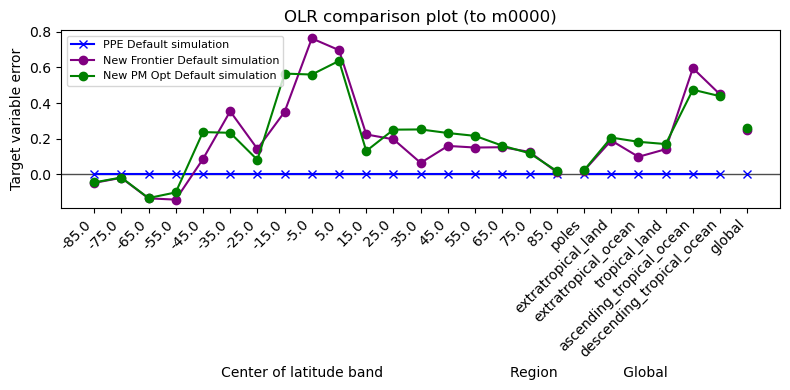

In [93]:
datasets = [
    {'data': control,  'label': 'PPE Default simulation', 'color': 'blue', 'marker': 'x'},
    {'data': newnew_default_data_small,  'label': 'New Frontier Default simulation', 'color': 'purple', 'marker': 'o'},
    {'data': newnewnew_default_data_small,'label': 'New PM Opt Default simulation',   'color': 'green',  'marker': 'o'},
]

plot_variable_comparison(
    datasets     = datasets,
    control      = control,
    area         = area,
    lat          = lat,
    lon          = lon,
    regions_file = regions_file,
    title        = 'OLR',
    variable     = 'LW_flux_up_at_model_top'
)

### Other plotting method

dict_keys([-85.0, -75.0, -65.0, -55.0, -45.0, -35.0, -25.0, -15.0, -5.0, 5.0, 15.0, 25.0, 35.0, 45.0, 55.0, 65.0, 75.0, 85.0])
18 6 25


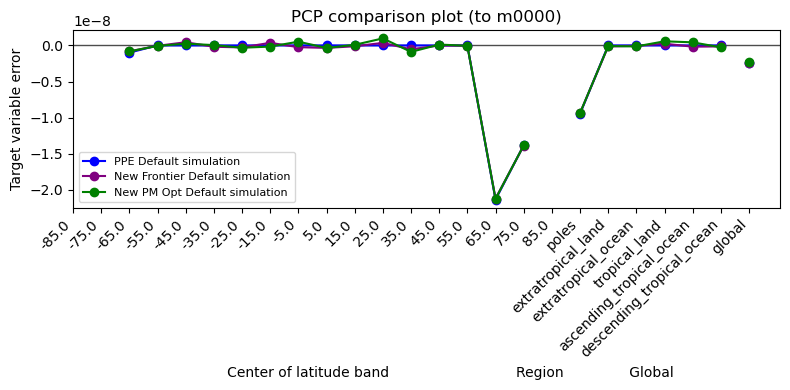

In [75]:
placeholder_zrgdataset_train = PCP_train
title = 'PCP'
#precip_total_surf_mass_flux
#TotalLiqWaterPath
#SW_flux_up_at_model_top
#LW_flux_up_at_model_top


# Configuration
datasets = [
    {
        'data': (control.precip_total_surf_mass_flux),
        #'data': (control.LiqWaterPath + control.RainWaterPath)
        'label': 'PPE Default simulation',
        'color': 'blue',
        'marker': 'o'
    },
    {
        'data': (newnew_default_data_small.precip_total_surf_mass_flux),
        'label': 'New Frontier Default simulation',
        'color': 'purple',
        'marker': 'o'
    },
        {
        'data': (newnewnew_default_data_small.precip_total_surf_mass_flux),
        'label': 'New PM Opt Default simulation',
        'color': 'green',
        'marker': 'o'
    }
]

# Calculate means for all datasets
results = []
for dataset in datasets:
    result = {
        'zonal': zonal_means_native(dataset['data'], area, lat, lon),
        'regional': regional_means_native(dataset['data'], area, regions_file),
        'global': np.array([global_means_native(dataset['data'], area)]),
        'label': dataset['label'],
        'color': dataset['color'],
        'marker': dataset['marker']
    }
    results.append(result)

# Extract keys and create x positions (using first dataset as reference)
zonal_keys = list(results[0]['zonal'].keys())
regional_keys = list(results[0]['regional'].keys())
array_labels = ['global']
print(results[0]['zonal'].keys())

z_num = len(zonal_keys)
r_num = len(regional_keys)
all_num = z_num + r_num + 1
print(z_num, r_num, all_num)

x_zonal = range(z_num)
x_regional = range(z_num, z_num + r_num)
x_global = range(z_num + r_num, z_num + r_num + 1)

# Create plot
plt.figure(figsize=(8, 4))
plt.axhline(y=0, color="black", linewidth=1, zorder=1, alpha=0.7)

# Plot each dataset
for result in results:
    zonal_values = list(result['zonal'].values())
    regional_values = list(result['regional'].values())
    global_value = result['global'][0]
    
    # Plot zonal means
    plt.plot(x_zonal, 
             np.array(zonal_values) - placeholder_zrgdataset_train.iloc[0, all_num:z_num+all_num],
             #np.array(zonal_values) - DY2_OLR_zrg_ppedataset.iloc[0, 0:z_num],
             f'-{result["marker"]}', 
             label=result['label'], 
             color=result['color'])
    
    # Plot regional means
    plt.plot(x_regional, 
             np.array(regional_values) - placeholder_zrgdataset_train.iloc[0, all_num+z_num:(z_num+r_num)+all_num],
             #np.array(regional_values) - DY2_OLR_zrg_ppedataset.iloc[0, z_num:(z_num+r_num)],
             f'-{result["marker"]}', 
             color=result['color'])
    
    # Plot global mean
    plt.plot(x_global, 
             global_value - placeholder_zrgdataset_train.iloc[0, -1], 
             #global_value - DY2_OLR_zrg_ppedataset.iloc[0, -1],
             f'-{result["marker"]}', 
             color=result['color'])

# Customize axes
all_keys = zonal_keys + regional_keys + array_labels
all_positions = list(x_zonal) + list(x_regional) + list(x_global)

plt.xticks(all_positions, all_keys, rotation=45, ha='right')
plt.xlabel("           Center of latitude band                             Region               Global")
plt.ylabel("Target variable error")
plt.title(title+" comparison plot (to m0000)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

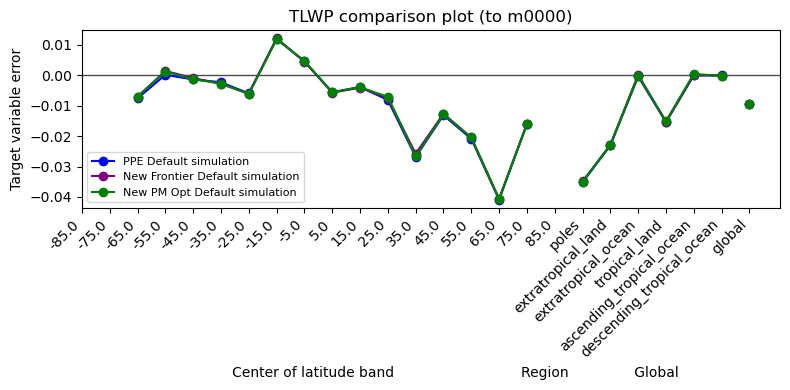

In [78]:
placeholder_zrgdataset_train = TLWP_train
title = 'TLWP'
#precip_total_surf_mass_flux
#TotalLiqWaterPath
#SW_flux_up_at_model_top
#LW_flux_up_at_model_top


# Configuration
datasets = [
    {
        #'data': (control.precip_total_surf_mass_flux),
        'data': (control.LiqWaterPath + control.RainWaterPath),
        'label': 'PPE Default simulation',
        'color': 'blue',
        'marker': 'o'
    },
    {
        'data': (newnew_default_data_small.TotalLiqWaterPath),
        'label': 'New Frontier Default simulation',
        'color': 'purple',
        'marker': 'o'
    },
        {
        'data': (newnewnew_default_data_small.TotalLiqWaterPath),
        'label': 'New PM Opt Default simulation',
        'color': 'green',
        'marker': 'o'
    }
]

# Calculate means for all datasets
results = []
for dataset in datasets:
    result = {
        'zonal': zonal_means_native(dataset['data'], area, lat, lon),
        'regional': regional_means_native(dataset['data'], area, regions_file),
        'global': np.array([global_means_native(dataset['data'], area)]),
        'label': dataset['label'],
        'color': dataset['color'],
        'marker': dataset['marker']
    }
    results.append(result)

# Extract keys and create x positions (using first dataset as reference)
zonal_keys = list(results[0]['zonal'].keys())
regional_keys = list(results[0]['regional'].keys())
array_labels = ['global']

z_num = len(zonal_keys)
r_num = len(regional_keys)
all_num = z_num + r_num + 1

x_zonal = range(z_num)
x_regional = range(z_num, z_num + r_num)
x_global = range(z_num + r_num, z_num + r_num + 1)

# Create plot
plt.figure(figsize=(8, 4))
plt.axhline(y=0, color="black", linewidth=1, zorder=1, alpha=0.7)

# Plot each dataset
for result in results:
    zonal_values = list(result['zonal'].values())
    regional_values = list(result['regional'].values())
    global_value = result['global'][0]
    
    # Plot zonal means
    plt.plot(x_zonal, 
             np.array(zonal_values) - placeholder_zrgdataset_train.iloc[0, all_num:z_num+all_num],
             #np.array(zonal_values) - DY2_OLR_zrg_ppedataset.iloc[0, 0:z_num],
             f'-{result["marker"]}', 
             label=result['label'], 
             color=result['color'])
    
    # Plot regional means
    plt.plot(x_regional, 
             np.array(regional_values) - placeholder_zrgdataset_train.iloc[0, all_num+z_num:(z_num+r_num)+all_num],
             #np.array(regional_values) - DY2_OLR_zrg_ppedataset.iloc[0, z_num:(z_num+r_num)],
             f'-{result["marker"]}', 
             color=result['color'])
    
    # Plot global mean
    plt.plot(x_global, 
             global_value - placeholder_zrgdataset_train.iloc[0, -1], 
             #global_value - DY2_OLR_zrg_ppedataset.iloc[0, -1],
             f'-{result["marker"]}', 
             color=result['color'])

# Customize axes
all_keys = zonal_keys + regional_keys + array_labels
all_positions = list(x_zonal) + list(x_regional) + list(x_global)

plt.xticks(all_positions, all_keys, rotation=45, ha='right')
plt.xlabel("           Center of latitude band                             Region               Global")
plt.ylabel("Target variable error")
plt.title(title+" comparison plot (to m0000)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

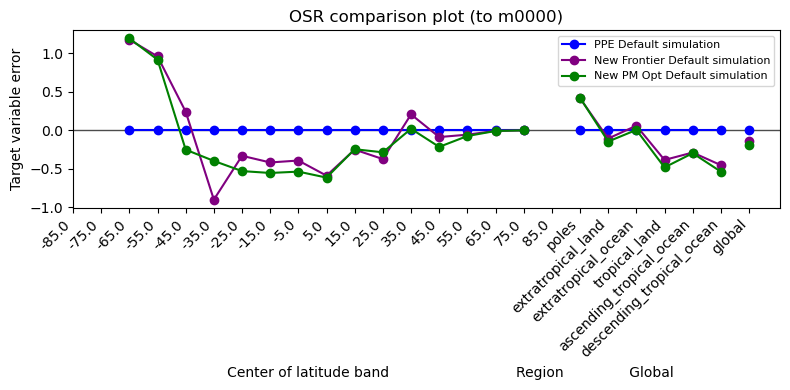

In [86]:
placeholder_zrgdataset_train = OSR_train
title = 'OSR'
#precip_total_surf_mass_flux
#TotalLiqWaterPath
#SW_flux_up_at_model_top
#LW_flux_up_at_model_top


# Configuration
datasets = [
    {
        'data': (control.SW_flux_up_at_model_top),
        #'data': (control.LiqWaterPath + control.RainWaterPath),
        'label': 'PPE Default simulation',
        'color': 'blue',
        'marker': 'o'
    },
    {
        'data': (newnew_default_data_small.SW_flux_up_at_model_top),
        'label': 'New Frontier Default simulation',
        'color': 'purple',
        'marker': 'o'
    },
        {
        'data': (newnewnew_default_data_small.SW_flux_up_at_model_top),
        'label': 'New PM Opt Default simulation',
        'color': 'green',
        'marker': 'o'
    }
]

# Calculate means for all datasets
results = []
for dataset in datasets:
    result = {
        'zonal': zonal_means_native(dataset['data'], area, lat, lon),
        'regional': regional_means_native(dataset['data'], area ,regions_file),
        'global': np.array([global_means_native(dataset['data'], area)]),
        'label': dataset['label'],
        'color': dataset['color'],
        'marker': dataset['marker']
    }
    results.append(result)

# Extract keys and create x positions (using first dataset as reference)
zonal_keys = list(results[0]['zonal'].keys())
regional_keys = list(results[0]['regional'].keys())
array_labels = ['global']

z_num = len(zonal_keys)
r_num = len(regional_keys)
all_num = z_num + r_num + 1

x_zonal = range(z_num)
x_regional = range(z_num, z_num + r_num)
x_global = range(z_num + r_num, z_num + r_num + 1)

# Create plot
plt.figure(figsize=(8, 4))
plt.axhline(y=0, color="black", linewidth=1, zorder=1, alpha=0.7)

# Plot each dataset
for result in results:
    zonal_values = list(result['zonal'].values())
    regional_values = list(result['regional'].values())
    global_value = result['global'][0]
    
    # Plot zonal means
    plt.plot(x_zonal, 
             np.array(zonal_values) - placeholder_zrgdataset_train.iloc[0, all_num:z_num+all_num],
             #np.array(zonal_values) - DY2_OLR_zrg_ppedataset.iloc[0, 0:z_num],
             f'-{result["marker"]}', 
             label=result['label'], 
             color=result['color'])
    
    # Plot regional means
    plt.plot(x_regional, 
             np.array(regional_values) - placeholder_zrgdataset_train.iloc[0, all_num+z_num:(z_num+r_num)+all_num],
             #np.array(regional_values) - DY2_OLR_zrg_ppedataset.iloc[0, z_num:(z_num+r_num)],
             f'-{result["marker"]}', 
             color=result['color'])
    
    # Plot global mean
    plt.plot(x_global, 
             global_value - placeholder_zrgdataset_train.iloc[0, -1], 
             #global_value - DY2_OLR_zrg_ppedataset.iloc[0, -1],
             f'-{result["marker"]}', 
             color=result['color'])

# Customize axes
all_keys = zonal_keys + regional_keys + array_labels
all_positions = list(x_zonal) + list(x_regional) + list(x_global)

plt.xticks(all_positions, all_keys, rotation=45, ha='right')
plt.xlabel("           Center of latitude band                             Region               Global")
plt.ylabel("Target variable error")
plt.title(title+" comparison plot (to m0000)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

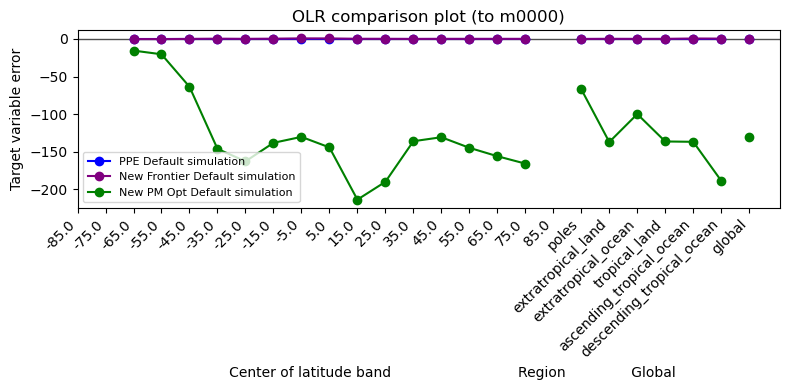

In [87]:
placeholder_zrgdataset_train = OLR_train
title = 'OLR'
#precip_total_surf_mass_flux
#TotalLiqWaterPath
#SW_flux_up_at_model_top
#LW_flux_up_at_model_top


# Configuration
datasets = [
    {
        'data': (control.LW_flux_up_at_model_top),
        #'data': (control.LiqWaterPath + control.RainWaterPath),
        'label': 'PPE Default simulation',
        'color': 'blue',
        'marker': 'o'
    },
    {
        'data': (newnew_default_data_small.LW_flux_up_at_model_top),
        'label': 'New Frontier Default simulation',
        'color': 'purple',
        'marker': 'o'
    },
        {
        'data': (newnewnew_default_data_small.SW_flux_up_at_model_top),
        'label': 'New PM Opt Default simulation',
        'color': 'green',
        'marker': 'o'
    }
]

# Calculate means for all datasets
results = []
for dataset in datasets:
    result = {
        'zonal': zonal_means_native(dataset['data'], area, lat, lon),
        'regional': regional_means_native(dataset['data'], area, regions_file),
        'global': np.array([global_means_native(dataset['data'], area)]),
        'label': dataset['label'],
        'color': dataset['color'],
        'marker': dataset['marker']
    }
    results.append(result)

# Extract keys and create x positions (using first dataset as reference)
zonal_keys = list(results[0]['zonal'].keys())
regional_keys = list(results[0]['regional'].keys())
array_labels = ['global']

z_num = len(zonal_keys)
r_num = len(regional_keys)
all_num = z_num + r_num + 1

x_zonal = range(z_num)
x_regional = range(z_num, z_num + r_num)
x_global = range(z_num + r_num, z_num + r_num + 1)

# Create plot
plt.figure(figsize=(8, 4))
plt.axhline(y=0, color="black", linewidth=1, zorder=1, alpha=0.7)

# Plot each dataset
for result in results:
    zonal_values = list(result['zonal'].values())
    regional_values = list(result['regional'].values())
    global_value = result['global'][0]
    
    # Plot zonal means
    plt.plot(x_zonal, 
             np.array(zonal_values) - placeholder_zrgdataset_train.iloc[0, all_num:z_num+all_num],
             #np.array(zonal_values) - DY2_OLR_zrg_ppedataset.iloc[0, 0:z_num],
             f'-{result["marker"]}', 
             label=result['label'], 
             color=result['color'])
    
    # Plot regional means
    plt.plot(x_regional, 
             np.array(regional_values) - placeholder_zrgdataset_train.iloc[0, all_num+z_num:(z_num+r_num)+all_num],
             #np.array(regional_values) - DY2_OLR_zrg_ppedataset.iloc[0, z_num:(z_num+r_num)],
             f'-{result["marker"]}', 
             color=result['color'])
    
    # Plot global mean
    plt.plot(x_global, 
             global_value - placeholder_zrgdataset_train.iloc[0, -1], 
             #global_value - DY2_OLR_zrg_ppedataset.iloc[0, -1],
             f'-{result["marker"]}', 
             color=result['color'])

# Customize axes
all_keys = zonal_keys + regional_keys + array_labels
all_positions = list(x_zonal) + list(x_regional) + list(x_global)

plt.xticks(all_positions, all_keys, rotation=45, ha='right')
plt.xlabel("           Center of latitude band                             Region               Global")
plt.ylabel("Target variable error")
plt.title(title+" comparison plot (to m0000)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Validating optimal runs

In [28]:
##two ways to get these masks
mask_path ='/global/cfs/cdirs/e3sm/jpaige3/mahf708_newvs_surrogate/Autotuning-NGD/src/scream-jp/surrogate_and_optimization/'

DY1_PCP_mask = xr.open_dataset(mask_path+'/masks/precip_1_output.nc').squeeze('time', drop=True)
DY2_PCP_mask = xr.open_dataset(mask_path+'/masks/precip_2_output.nc').squeeze('time', drop=True)
DY1_TLWP_mask = xr.open_dataset(mask_path+'/masks/tlwp_1_output.nc').squeeze('time', drop=True)
DY2_TLWP_mask = xr.open_dataset(mask_path+'/masks/tlwp_2_output.nc').squeeze('time', drop=True)

#len(np.where(((DY1_TLWP_mask.to_dataarray()[0]) == True).values)[0]) - ncol drops from 21600 to 15313

In [29]:
### These are the first optimal params run in SCREAM in Oct 2025
optimal_params_old = np.array([1.00000000e-01, 8.72596066e+00, 5.81553407e-01, 1.00000000e-01,
                                  3.97719941e-01, 1.00000000e+00, 4.20402644e-02, 4.36854065e-02,
                                  1.00000000e-01, 1.00000000e+00, 1.00000000e-01, 1.00000000e-02,
                                  2.93051240e-01, 9.36429137e+06, 1.65530607e+00, 7.70072093e-11, 1.4575680588303337])

In [30]:
### These are the second optimal params run in SCREAM in Mar 2026
optimal_params_final = np.array( [7.73763730e-01, 1.00000000e+01, 8.01645575e-01, 1.00097089e-01,
                                  4.62191061e-01, 9.95946000e-01, 4.00166116e-02, 9.99999992e-02,
                                  1.23519078e-01, 1.00000000e+00, 6.17443728e-01, 1.00000000e-02,
                                  2.90610253e-01, 1.00000000e+07, 1.71766215e+00, 0.00000000e+00, 0.9893306717983437])

In [31]:
print('Predictions:')
params_to_cost_print(X_pipe_sk_minmax.transform(optimal_params_old[0:-1].reshape(1, -1))[0])
params_to_cost_print(X_pipe_sk_minmax.transform(optimal_params_final[0:-1].reshape(1, -1))[0])

Predictions:


NameError: name 'params_to_cost_print' is not defined

In [26]:
old_opt_basin1_rank1_data = xr.open_dataset('/global/cfs/cdirs/e3sm/jpaige3/optimizing_SCREAM_runs/optbasin1rank1_DY2/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc')
old_opt_basin1_rank1_data_small = old_opt_basin1_rank1_data.get(to_keep)
old_opt_basin1_rank1_data_small['TotalLiqWaterPath'] = (old_opt_basin1_rank1_data_small.LiqWaterPath + old_opt_basin1_rank1_data_small.RainWaterPath)
old_opt_basin1_rank1_data_small.squeeze('time')

NameError: name 'to_keep' is not defined

In [32]:
PM_DY1_opt_mar26_data = xr.open_dataset('/global/cfs/cdirs/e3sm/jpaige3/optimizing_SCREAM_runs/optmar26_DY1_hassan/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2016-08-07-00000.nc')
PM_DY1_opt_mar26_data_small = PM_DY1_opt_mar26_data.get(to_keep)
PM_DY1_opt_mar26_data_small['TotalLiqWaterPath'] = (PM_DY1_opt_mar26_data_small.LiqWaterPath + PM_DY1_opt_mar26_data_small.RainWaterPath)
PM_DY1_opt_mar26_data_small.squeeze('time')

<xarray.Dataset> Size: 518kB
Dimensions:                      (ncol: 21600)
Coordinates:
    time                         object 8B 2016-08-08 00:00:00
Dimensions without coordinates: ncol
Data variables:
    precip_total_surf_mass_flux  (ncol) float32 86kB ...
    LiqWaterPath                 (ncol) float32 86kB ...
    RainWaterPath                (ncol) float32 86kB ...
    SW_flux_up_at_model_top      (ncol) float32 86kB ...
    LW_flux_up_at_model_top      (ncol) float32 86kB ...
    TotalLiqWaterPath            (ncol) float32 86kB 0.08955 ... 0.002254
Attributes: (12/22)
    case_t0:                      2016-08-01-00000
    run_t0:                       2016-08-06-00000
    averaging_type:               AVERAGE
    averaging_frequency_units:    nhours
    averaging_frequency:          24
    file_max_storage_type:        num_snapshots
    ...                           ...
    contact:                      e3sm-data-support@llnl.gov
    institution_id:               E3SM-Project
    realm:                        atmos
    history:                      created on Tue Mar 31 11:51:03 2026
    Conventions:                  CF-1.8
    product:                      model-output

In [33]:
PM_DY2_opt_mar26_data = xr.open_dataset('/pscratch/sd/j/jpaige3/e3sm_scratch/pm-gpu/p01-dec2-2024-2444ff44ec/ii1024/opt_mar_26/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc')
PM_DY2_opt_mar26_data_small = PM_DY2_opt_mar26_data.get(to_keep)
PM_DY2_opt_mar26_data_small['TotalLiqWaterPath'] = (PM_DY2_opt_mar26_data_small.LiqWaterPath + PM_DY2_opt_mar26_data_small.RainWaterPath)
PM_DY2_opt_mar26_data_small.squeeze('time')

<xarray.Dataset> Size: 518kB
Dimensions:                      (ncol: 21600)
Coordinates:
    time                         object 8B 2020-01-27 00:00:00
Dimensions without coordinates: ncol
Data variables:
    precip_total_surf_mass_flux  (ncol) float32 86kB ...
    LiqWaterPath                 (ncol) float32 86kB ...
    RainWaterPath                (ncol) float32 86kB ...
    SW_flux_up_at_model_top      (ncol) float32 86kB ...
    LW_flux_up_at_model_top      (ncol) float32 86kB ...
    TotalLiqWaterPath            (ncol) float32 86kB 0.06531 0.108 ... 0.01622
Attributes: (12/22)
    case_t0:                      2020-01-20-00000
    run_t0:                       2020-01-25-00000
    averaging_type:               AVERAGE
    averaging_frequency_units:    nhours
    averaging_frequency:          24
    file_max_storage_type:        num_snapshots
    ...                           ...
    contact:                      e3sm-data-support@llnl.gov
    institution_id:               E3SM-Project
    realm:                        atmos
    history:                      created on Fri Apr  3 04:50:11 2026
    Conventions:                  CF-1.8
    product:                      model-output

In [34]:
#DY1
PM_DY1_opt_mar26_data_small['precip_total_surf_mass_flux'] = PM_DY1_opt_mar26_data_small.precip_total_surf_mass_flux.where(~np.isnan(DY1_PCP_obs))
PM_DY1_opt_mar26_data_small['TotalLiqWaterPath'] = PM_DY1_opt_mar26_data_small.TotalLiqWaterPath.where(~np.isnan(DY1_TLWP_obs))
PM_DY1_opt_mar26_data_small['SW_flux_up_at_model_top'] = PM_DY1_opt_mar26_data_small.SW_flux_up_at_model_top.where(~np.isnan(DY1_OSR_obs))
PM_DY1_opt_mar26_data_small['LW_flux_up_at_model_top'] = PM_DY1_opt_mar26_data_small.LW_flux_up_at_model_top.where(~np.isnan(DY1_OLR_obs))

#DY2
PM_DY2_opt_mar26_data_small['precip_total_surf_mass_flux'] = PM_DY2_opt_mar26_data_small.precip_total_surf_mass_flux.where(~np.isnan(DY2_PCP_obs))
PM_DY2_opt_mar26_data_small['TotalLiqWaterPath'] = PM_DY2_opt_mar26_data_small.TotalLiqWaterPath.where(~np.isnan(DY2_TLWP_obs))
PM_DY2_opt_mar26_data_small['SW_flux_up_at_model_top'] = PM_DY2_opt_mar26_data_small.SW_flux_up_at_model_top.where(~np.isnan(DY2_OSR_obs))
PM_DY2_opt_mar26_data_small['LW_flux_up_at_model_top'] = PM_DY2_opt_mar26_data_small.LW_flux_up_at_model_top.where(~np.isnan(DY2_OLR_obs))


In [35]:
#typically when output from basing hopping, they will be normalized/transformed
optimal_params_norm = X_pipe_sk_minmax.transform(optimal_params_final[0:-1].reshape(1,-1))

In [36]:
print('default:')
print(params_to_cost_print(X_train_norm[0]))
print('optimal:')
print(params_to_cost_print(optimal_params_norm[0])) #

default:


NameError: name 'params_to_cost_print' is not defined

##### Must transform back before using in run

In [37]:
final_preds_norm, final_preds_var_norm = model_gp.predict(optimal_params_norm.reshape(1,-1))
PCP_final_preds_norm  = final_preds_norm[:, :, 0]
TLWP_final_preds_norm = final_preds_norm[:, :, 1]
OSR_final_preds_norm  = final_preds_norm[:, :, 2]
OLR_final_preds_norm  = final_preds_norm[:, :, 3]

PCP_final_preds  = Y_pipe_sk_ss_PCP.inverse_transform(PCP_final_preds_norm)[0]
TLWP_final_preds = Y_pipe_sk_ss_TLWP.inverse_transform(TLWP_final_preds_norm)[0]
OSR_final_preds  = Y_pipe_sk_ss_OSR.inverse_transform(OSR_final_preds_norm)[0]
OLR_final_preds  = Y_pipe_sk_ss_OLR.inverse_transform(OLR_final_preds_norm)[0]

# Marginal SDs in physical space: std_phys = std_norm * scaler.scale_
# (StandardScaler: y = y_norm * scale + mean, so std scales linearly)
PCP_final_preds_sd  = (np.sqrt(final_preds_var_norm[:, :, 0]) * Y_pipe_sk_ss_PCP.scale_)[0]
TLWP_final_preds_sd = (np.sqrt(final_preds_var_norm[:, :, 1]) * Y_pipe_sk_ss_TLWP.scale_)[0]
OSR_final_preds_sd  = (np.sqrt(final_preds_var_norm[:, :, 2]) * Y_pipe_sk_ss_OSR.scale_)[0]
OLR_final_preds_sd  = (np.sqrt(final_preds_var_norm[:, :, 3]) * Y_pipe_sk_ss_OLR.scale_)[0]

final_params = X_pipe_sk_minmax.inverse_transform(optimal_params_final[0:-1].reshape(1,-1))


## Plotting

##### Comparison plots

In [38]:
def plot_zrg_comparison(
    opt_data,
    PPE_data,
    obs_data,
    opt_preds,
    area,
    lat,
    lon,
    regions_file,
    all_num,
    r_num,
    z_num,
    ylim=None,
    axis_loc=None,
    dy="DY1",
    title="Target variable comparison plot",
    ylabel="Target variable error",
    opt_preds_sd=None,          # marginal SDs in physical units (same shape as opt_preds)
):
    # DY slice offset
    if dy == "DY1":
        col_start = 0
    elif dy == "DY2":
        col_start = all_num
    else:
        raise ValueError(f"dy must be 'DY1' or 'DY2', got '{dy}'")

    # Slice PPE and obs to the correct DY block
    PPE_slice  = PPE_data.iloc[:, col_start:col_start + all_num]
    obs_slice  = obs_data.iloc[:, col_start:col_start + all_num]
    pred_slice = opt_preds[col_start:col_start + all_num]

    # Compute zonal, regional, and global means
    dict1        = zonal_means_native(opt_data, area, lat, lon)
    dict2        = regional_means_native(opt_data, area, regions_file)
    global_array = np.array([global_means_native(opt_data, area)])

    # Extract and slice zonal keys/values
    keys1   = list(dict1.keys())[2:z_num+2]
    values1 = np.array(list(dict1.values())[2:z_num+2])

    # Regional keys/values
    keys2   = list(dict2.keys())
    values2 = np.array(list(dict2.values()))

    # x positions for each group
    x1 = list(range(z_num))
    x2 = list(range(z_num, z_num + r_num))
    x3 = list(range(z_num + r_num, all_num))

    # Compute bias terms
    ppe_bias      = PPE_slice - obs_slice.values
    default_bias  = (PPE_slice.loc['m0000'] - obs_slice.iloc[0]).to_numpy()
    pred_bias     = (pred_slice - obs_slice).iloc[0].to_numpy()
    zonal_bias    = values1 - obs_slice.iloc[0, 0:z_num].to_numpy()
    regional_bias = values2 - obs_slice.iloc[0, z_num:z_num+r_num].to_numpy()
    global_bias   = global_array - obs_slice.iloc[0, -1]

    # SD slice (if provided)
    if opt_preds_sd is not None:
        sd_slice = opt_preds_sd[col_start:col_start + all_num]

    # Plot
    fig, ax = plt.subplots(figsize=(8, 4))
    point_size = 30

    # PPE ensemble (gray scatter)
    for _, row in ppe_bias.iterrows():
        ax.scatter(range(all_num), row.to_numpy(), color='gray', alpha=0.25, s=point_size - 10)

    ax.axhline(y=0, color='black', linewidth=1, zorder=1, alpha=0.7)

    # Default (m0000)
    ax.plot(x1, default_bias[0:z_num],           '-o', color='red')
    ax.plot(x2, default_bias[z_num:z_num+r_num], '-o', color='red')
    ax.plot(x3, default_bias[-1:],               '-o', color='red', label='Default')

    # GP predictions (with optional ±1σ shading)
    ax.plot(x1, pred_bias[0:z_num],           '-s', color='darkviolet')
    ax.plot(x2, pred_bias[z_num:z_num+r_num], '-s', color='darkviolet')
    ax.plot(x3, pred_bias[-1:],               '-s', color='darkviolet', label='GP Preds')

    if opt_preds_sd is not None:
        ax.fill_between(x1,
                        pred_bias[0:z_num]           - 2*sd_slice[0:z_num],
                        pred_bias[0:z_num]           + 2*sd_slice[0:z_num],
                        color='darkviolet', alpha=0.2, label='GP ±2σ')
        ax.fill_between(x2,
                        pred_bias[z_num:z_num+r_num] - 2*sd_slice[z_num:z_num+r_num],
                        pred_bias[z_num:z_num+r_num] + 2*sd_slice[z_num:z_num+r_num],
                        color='darkviolet', alpha=0.2)
        ax.fill_between(x3,
                        pred_bias[-1:]               - 2*sd_slice[-1:],
                        pred_bias[-1:]               + 2*sd_slice[-1:],
                        color='darkviolet', alpha=0.2)

    # Optimum
    ax.plot(x1, zonal_bias,    '-^', color='mediumblue', label='Optimum')
    ax.plot(x2, regional_bias, '-^', color='mediumblue')
    ax.plot(x3, global_bias,   '-^', color='mediumblue')

    # x-axis labels
    all_keys      = keys1 + keys2 + ['global']
    all_positions = x1 + x2 + x3
    ax.set_xticks(all_positions)
    ax.set_xticklabels(all_keys, rotation=45, ha='right')
    ax.set_xlabel("          Center of latitude band                                Region               Global")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{dy} {title}")

    if axis_loc is not None:
        ax.legend(fontsize=8, loc=axis_loc)
    else:
        ax.legend(fontsize=8) #, loc='upper right'

    if ylim is not None:
        ax.set_ylim(ylim)

    plt.tight_layout()
    plt.show()


In [44]:
def plot_zrg_comparison_TLWP(
    opt_data,
    PPE_data,
    obs_data,
    opt_preds,
    area,
    lat,
    lon,
    regions_file,
    all_num,
    r_num,
    z_num,
    ylim=None,
    axis_loc=None,
    dy="DY1",
    title="Target variable comparison plot",
    ylabel="Target variable error",
    opt_preds_sd=None,
):
    # DY slice offset
    if dy == "DY1":
        col_start = 0
    elif dy == "DY2":
        col_start = all_num
    else:
        raise ValueError(f"dy must be 'DY1' or 'DY2', got '{dy}'")

    # Slice PPE and obs to the correct DY block
    PPE_slice  = PPE_data.iloc[:, col_start:col_start + all_num]
    obs_slice  = obs_data.iloc[:, col_start:col_start + all_num]
    pred_slice = opt_preds[col_start:col_start + all_num]

    # Compute zonal, regional, and global means
    dict1        = zonal_means_native(opt_data, area, lat, lon)
    dict2        = regional_means_native(opt_data, area, regions_file)
    global_array = np.array([global_means_native(opt_data, area)])

    # Extract and slice zonal keys/values
    keys1   = list(dict1.keys())[2:z_num+2]
    values1 = np.array(list(dict1.values())[2:z_num+2])

    # Regional keys/values — drop indices 1 and 3 (2nd and 4th regions)
    drop_idx = [1, 3]
    keys2   = [k for i, k in enumerate(dict2.keys()) if i not in drop_idx]
    values2 = np.delete(np.array(list(dict2.values())), drop_idx)
    r_num_plot = r_num - len(drop_idx)

    # x positions for each group
    x1 = list(range(z_num))
    x2 = list(range(z_num, z_num + r_num_plot))
    x3 = list(range(z_num + r_num_plot, z_num + r_num_plot + 1))

    # Compute bias terms
    ppe_bias      = PPE_slice - obs_slice.values
    default_bias  = (PPE_slice.loc['m0000'] - obs_slice.iloc[0]).to_numpy()
    pred_bias     = (pred_slice - obs_slice).iloc[0].to_numpy()
    zonal_bias    = values1 - obs_slice.iloc[0, 0:z_num].to_numpy()

    # Regional obs/default/pred biases: drop indices 1 and 3
    regional_obs     = np.delete(obs_slice.iloc[0, z_num:z_num+r_num].to_numpy(), drop_idx)
    regional_bias    = values2 - regional_obs
    default_regional = np.delete(default_bias[z_num:z_num+r_num], drop_idx)
    pred_regional    = np.delete(pred_bias[z_num:z_num+r_num], drop_idx)

    global_bias = global_array - obs_slice.iloc[0, -1]

    # SD slice (if provided)
    if opt_preds_sd is not None:
        sd_slice    = opt_preds_sd[col_start:col_start + all_num]
        sd_regional = np.delete(sd_slice[z_num:z_num+r_num], drop_idx)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 4))
    point_size = 30

    # PPE ensemble (gray scatter) — drop columns at z_num+1 and z_num+3
    ppe_cols_to_drop = [z_num + i for i in drop_idx]
    ppe_bias_plot = ppe_bias.drop(ppe_bias.columns[ppe_cols_to_drop], axis=1)
    for _, row in ppe_bias_plot.iterrows():
        ax.scatter(range(all_num - len(drop_idx)), row.to_numpy(), color='gray', alpha=0.25, s=point_size - 10)

    ax.axhline(y=0, color='black', linewidth=1, zorder=1, alpha=0.7)

    # Default (m0000)
    ax.plot(x1, default_bias[0:z_num],  '-o', color='red')
    ax.plot(x2, default_regional,        '-o', color='red')
    ax.plot(x3, default_bias[-1:],       '-o', color='red', label='Default')

    # GP predictions (with optional ±2σ shading)
    ax.plot(x1, pred_bias[0:z_num], '-s', color='darkviolet')
    ax.plot(x2, pred_regional,       '-s', color='darkviolet')
    ax.plot(x3, pred_bias[-1:],      '-s', color='darkviolet', label='GP Preds')

    if opt_preds_sd is not None:
        ax.fill_between(x1,
                        pred_bias[0:z_num] - 2*sd_slice[0:z_num],
                        pred_bias[0:z_num] + 2*sd_slice[0:z_num],
                        color='darkviolet', alpha=0.2, label='GP ±2σ')
        ax.fill_between(x2,
                        pred_regional - 2*sd_regional,
                        pred_regional + 2*sd_regional,
                        color='darkviolet', alpha=0.2)
        ax.fill_between(x3,
                        pred_bias[-1:] - 2*sd_slice[-1:],
                        pred_bias[-1:] + 2*sd_slice[-1:],
                        color='darkviolet', alpha=0.2)

    # Optimum
    ax.plot(x1, zonal_bias,    '-^', color='mediumblue', label='Optimum')
    ax.plot(x2, regional_bias, '-^', color='mediumblue')
    ax.plot(x3, global_bias,   '-^', color='mediumblue')

    # x-axis labels
    all_keys      = keys1 + keys2 + ['global']
    all_positions = x1 + x2 + x3
    ax.set_xticks(all_positions)
    ax.set_xticklabels(all_keys, rotation=45, ha='right')
    ax.set_xlabel("          Center of latitude band                                Region               Global")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{dy} {title}")

    if axis_loc is not None:
        ax.legend(fontsize=8, loc=axis_loc)
    else:
        ax.legend(fontsize=8)

    if ylim is not None:
        ax.set_ylim(ylim)

    plt.tight_layout()
    plt.show()

In [39]:
all_num = 22

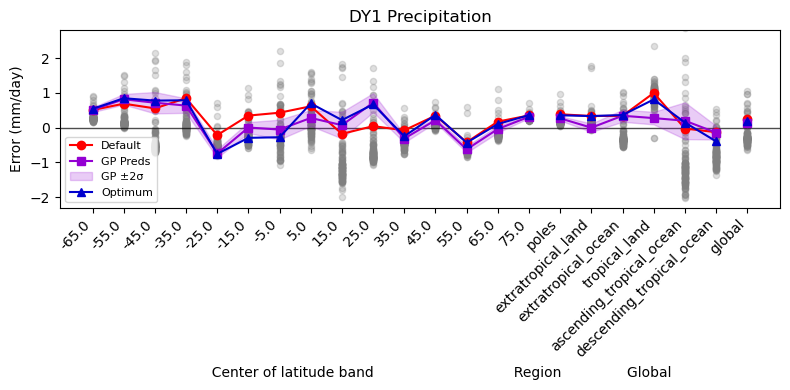

In [40]:
plot_zrg_comparison(
    opt_data     = PM_DY1_opt_mar26_data_small['precip_total_surf_mass_flux']*1e3*24*3600,
    PPE_data     = PCP_train*1e3*24*3600,
    obs_data     = PCP_zrg_obs*1e3*24*3600,
    opt_preds    = PCP_final_preds*1e3*24*3600,
    opt_preds_sd = PCP_final_preds_sd*1e3*24*3600,
    area=area, lat=lat, lon=lon, regions_file=regions_file,
    all_num=22, r_num=6, z_num=15,
    dy="DY1",
    title="Precipitation",
    ylabel="Error (mm/day)",
    ylim=(-2.3,2.8),
    axis_loc = 'lower left'
)


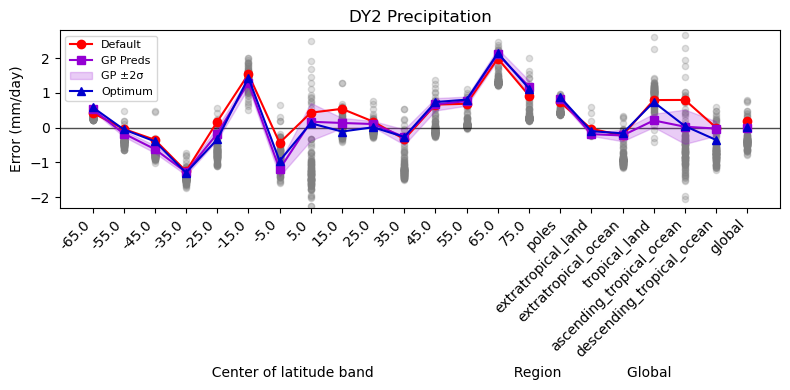

In [95]:
plot_zrg_comparison(
    opt_data     = PM_DY2_opt_mar26_data_small['precip_total_surf_mass_flux']*1e3*24*3600,
    PPE_data     = PCP_train*1e3*24*3600,
    obs_data     = PCP_zrg_obs*1e3*24*3600,
    opt_preds    = PCP_final_preds*1e3*24*3600,
    opt_preds_sd = PCP_final_preds_sd*1e3*24*3600,
    area=area, lat=lat, lon=lon, regions_file=regions_file,
    all_num=22, r_num=6, z_num=15,
    dy="DY2",
    title="Precipitation",
    ylabel="Error (mm/day)",
    ylim=(-2.3,2.8)
)


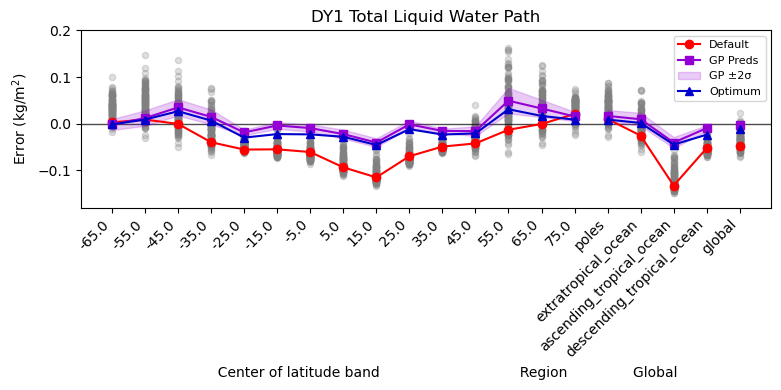

In [45]:
plot_zrg_comparison_TLWP(
    opt_data     = PM_DY1_opt_mar26_data_small['TotalLiqWaterPath'],
    PPE_data     = TLWP_train,
    obs_data     = TLWP_zrg_obs,
    opt_preds    = TLWP_final_preds,
    opt_preds_sd = TLWP_final_preds_sd,
    area=area, lat=lat, lon=lon, regions_file=regions_file,
    all_num=22, r_num=6, z_num=15,
    dy="DY1",
    title="Total Liquid Water Path",
    ylabel="Error (kg/m$^2$)",
    ylim=(-0.18,0.2)
)


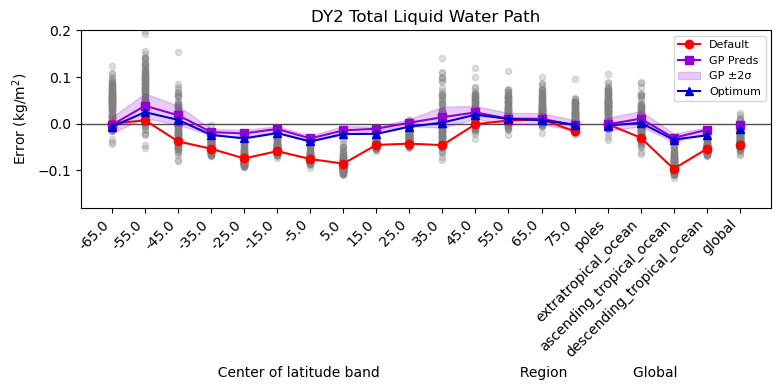

In [46]:
plot_zrg_comparison_TLWP(
    opt_data     = PM_DY2_opt_mar26_data_small['TotalLiqWaterPath'],
    PPE_data     = TLWP_train,
    obs_data     = TLWP_zrg_obs,
    opt_preds    = TLWP_final_preds,
    opt_preds_sd = TLWP_final_preds_sd,
    area=area, lat=lat, lon=lon, regions_file=regions_file,
    all_num=22, r_num=6, z_num=15,
    dy="DY2",
    title="Total Liquid Water Path",
    ylabel="Error (kg/m$^2$)",
    ylim=(-0.18,0.2)
)


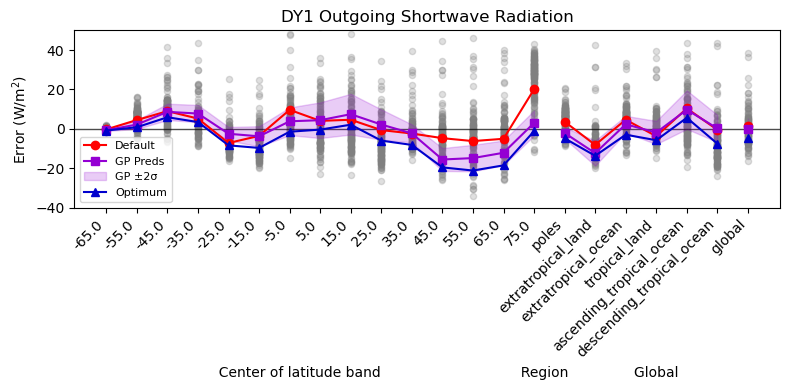

In [79]:
plot_zrg_comparison(
    opt_data     = PM_DY1_opt_mar26_data_small['SW_flux_up_at_model_top'],
    PPE_data     = OSR_train,
    obs_data     = OSR_zrg_obs,
    opt_preds    = OSR_final_preds,
    opt_preds_sd = OSR_final_preds_sd,
    area=area, lat=lat, lon=lon, regions_file=regions_file,
    all_num=22, r_num=6, z_num=15,
    dy="DY1",
    title="Outgoing Shortwave Radiation",
    ylabel="Error (W/m$^2$)",
    ylim=(-40, 50),
)


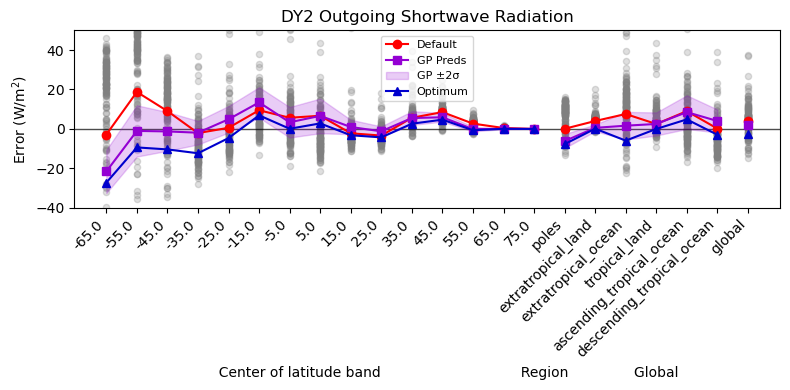

In [80]:
plot_zrg_comparison(
    opt_data     = PM_DY2_opt_mar26_data_small['SW_flux_up_at_model_top'],
    PPE_data     = OSR_train,
    obs_data     = OSR_zrg_obs,
    opt_preds    = OSR_final_preds,
    opt_preds_sd = OSR_final_preds_sd,
    area=area, lat=lat, lon=lon, regions_file=regions_file,
    all_num=22, r_num=6, z_num=15,
    dy="DY2",
    title="Outgoing Shortwave Radiation",
    ylabel="Error (W/m$^2$)",
    ylim=(-40, 50),
)


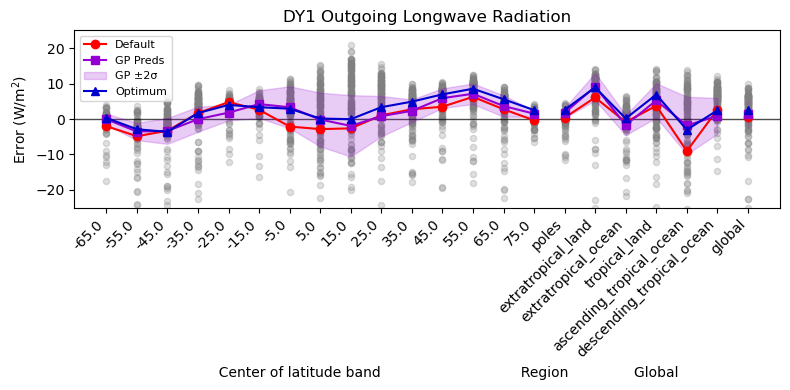

In [81]:
plot_zrg_comparison(
    opt_data     = PM_DY1_opt_mar26_data_small['LW_flux_up_at_model_top'],
    PPE_data     = OLR_train,
    obs_data     = OLR_zrg_obs,
    opt_preds    = OLR_final_preds,
    opt_preds_sd = OLR_final_preds_sd,
    area=area, lat=lat, lon=lon, regions_file=regions_file,
    all_num=22, r_num=6, z_num=15,
    dy="DY1",
    title="Outgoing Longwave Radiation",
    ylabel="Error (W/m$^2$)",
    ylim=(-25, 25),
)


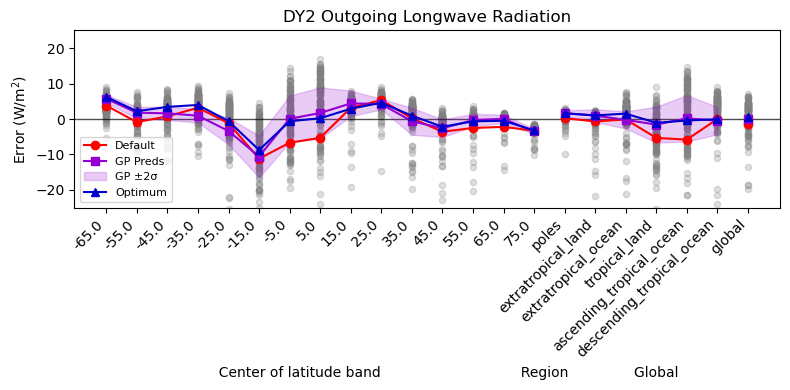

In [82]:
plot_zrg_comparison(
    opt_data     = PM_DY2_opt_mar26_data_small['LW_flux_up_at_model_top'],
    PPE_data     = OLR_train,
    obs_data     = OLR_zrg_obs,
    opt_preds    = OLR_final_preds,
    opt_preds_sd = OLR_final_preds_sd,
    area=area, lat=lat, lon=lon, regions_file=regions_file,
    all_num=22, r_num=6, z_num=15,
    dy="DY2",
    title="Outgoing Longwave Radiation",
    ylabel="Error (W/m$^2$)",
    ylim=(-25, 25),
)


##### Global averages

In [179]:
def plot_multi_variable_global_comparison(
    variables: list[dict],
    title="Global Average vs Error",
    ylabel="Relative Error (bias / obs)",
    ylim=None,
    #figsize=(4, 6),
):
    default_colours = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    x_positions = []
    ppe_biases  = []
    default_pts = []
    pred_pts    = []
    opt_pts     = []
    labels      = []

    for i, var in enumerate(variables):
        PPE_data  = var["PPE_data"]   # DataFrame: rows=members, single global column
        obs_data  = var["obs_data"]   # scalar, Series, or single-value DataFrame
        opt_preds = var["opt_preds"]  # scalar
        opt_data  = var["opt_data"]
        area      = var["area"]
        label     = var.get("label",  f"Var {i+1}")

        # ── Coerce obs to scalar ──────────────────────────────────────────────
        if hasattr(obs_data, "iloc"):
            obs_global = float(obs_data.iloc[0] if obs_data.ndim == 1 else obs_data.iloc[0, 0])
        else:
            obs_global = float(obs_data)

        if obs_global == 0:
            raise ValueError(f"Variable '{label}': obs global value is 0 — cannot normalise.")

        # ── Coerce PPE_data to a 1-D array of member values ──────────────────
        if PPE_data.ndim == 2:
            ppe_vals = PPE_data.iloc[:, 0].to_numpy(dtype=float)  # single global col
        else:
            ppe_vals = PPE_data.to_numpy(dtype=float)

        global_val = float(global_means_native(opt_data, area))

        ppe_bias_global     = (ppe_vals - obs_global)                        / abs(obs_global)
        default_bias_global = (float(PPE_data.iloc[0]) - obs_global) / abs(obs_global)
        pred_bias_global    = (float(opt_preds)  - obs_global)               / abs(obs_global)
        opt_bias_global     = (global_val        - obs_global)               / abs(obs_global)

        x_positions.append(i)
        ppe_biases.append(ppe_bias_global)
        default_pts.append(default_bias_global)
        pred_pts.append(pred_bias_global)
        opt_pts.append(opt_bias_global)
        labels.append(label)

    # ── Plot ──────────────────────────────────────────────────────────────────
    #fig, ax = plt.subplots(figsize=figsize)
    fig, ax = plt.subplots()

    for i, (x, ppe) in enumerate(zip(x_positions, ppe_biases)):
        ax.scatter(np.full(len(ppe), x), ppe, color="gray", alpha=0.3, s=20,
                   zorder=3)

    ax.scatter(x_positions, default_pts, marker="o", s=50, color="red",        zorder=4, label="Default")
    ax.scatter(x_positions, pred_pts,    marker="s", s=50, color="darkviolet", zorder=4, label="GP Preds")
    ax.scatter(x_positions, opt_pts,     marker="^", s=50, color="mediumblue", zorder=4, label="Optimum")

    ax.axhline(0, color="black", linewidth=0.9, alpha=0.7, zorder=1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.1f}%"))
    ax.legend(fontsize=8, loc="best")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.tight_layout()
    plt.show()

In [180]:
variables_DY1 = [
    {
        "opt_data":  PM_DY1_opt_mar26_data_small['precip_total_surf_mass_flux'],
        "PPE_data":  PCP_train.iloc[:, all_num-1],
        "obs_data":  PCP_zrg_obs.iloc[:, all_num-1],
        "opt_preds": PCP_final_preds[all_num-1],
        "area":      area,
        "label":     "PCP",
    },
    {
        "opt_data":  PM_DY1_opt_mar26_data_small['TotalLiqWaterPath'],
        "PPE_data":  TLWP_train.iloc[:, all_num-1],
        "obs_data":  TLWP_zrg_obs.iloc[:, all_num-1],
        "opt_preds": TLWP_final_preds[all_num-1],
        "area":      area,
        "label":     "TLWP",
    },
    {
        "opt_data":  PM_DY1_opt_mar26_data_small['SW_flux_up_at_model_top'],
        "PPE_data":  OSR_train.iloc[:, all_num-1],
        "obs_data":  OSR_zrg_obs.iloc[:, all_num-1],
        "opt_preds": OSR_final_preds[all_num-1],
        "area":      area,
        "label":     "OSR",
    },
    {
        "opt_data":  PM_DY1_opt_mar26_data_small['LW_flux_up_at_model_top'],
        "PPE_data":  OLR_train.iloc[:, all_num-1],
        "obs_data":  OLR_zrg_obs.iloc[:, all_num-1],
        "opt_preds": OLR_final_preds[all_num-1],
        "area":      area,
        "label":     "OLR",
    }
]

In [181]:
variables_DY2 = [
    {
        "opt_data":  PM_DY2_opt_mar26_data_small['precip_total_surf_mass_flux'],
        "PPE_data":  PCP_train.iloc[:, -1],
        "obs_data":  PCP_zrg_obs.iloc[:, -1],
        "opt_preds": PCP_final_preds[-1],
        "area":      area,
        "label":     "PCP",
    },
    {
        "opt_data":  PM_DY2_opt_mar26_data_small['TotalLiqWaterPath'],
        "PPE_data":  TLWP_train.iloc[:, -1],
        "obs_data":  TLWP_zrg_obs.iloc[:, -1],
        "opt_preds": TLWP_final_preds[-1],
        "area":      area,
        "label":     "TLWP",
    },
    {
        "opt_data":  PM_DY2_opt_mar26_data_small['SW_flux_up_at_model_top'],
        "PPE_data":  OSR_train.iloc[:, -1],
        "obs_data":  OSR_zrg_obs.iloc[:, -1],
        "opt_preds": OSR_final_preds[-1],
        "area":      area,
        "label":     "OSR",
    },
    {
        "opt_data":  PM_DY2_opt_mar26_data_small['LW_flux_up_at_model_top'],
        "PPE_data":  OLR_train.iloc[:, -1],
        "obs_data":  OLR_zrg_obs.iloc[:, -1],
        "opt_preds": OLR_final_preds[-1],
        "area":      area,
        "label":     "OLR",
    }
]

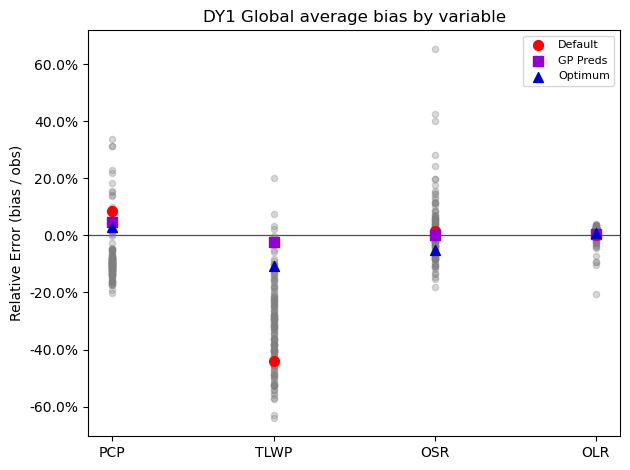

In [182]:
plot_multi_variable_global_comparison(variables = variables_DY1, 
                                      title= "DY1 Global average bias by variable")

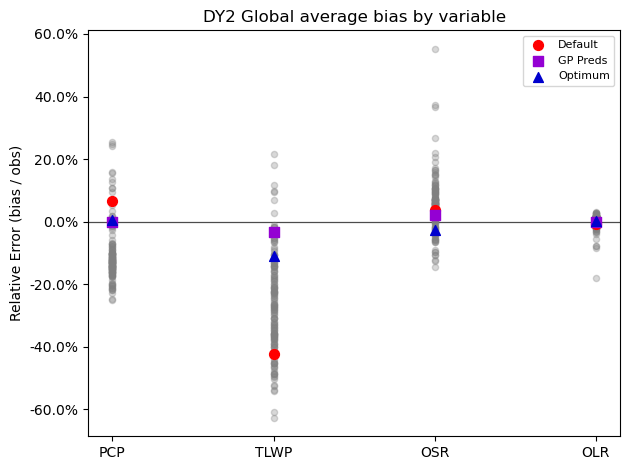

In [183]:
plot_multi_variable_global_comparison(variables = variables_DY2, 
                                      title= "DY2 Global average bias by variable")

#### Old Plotting

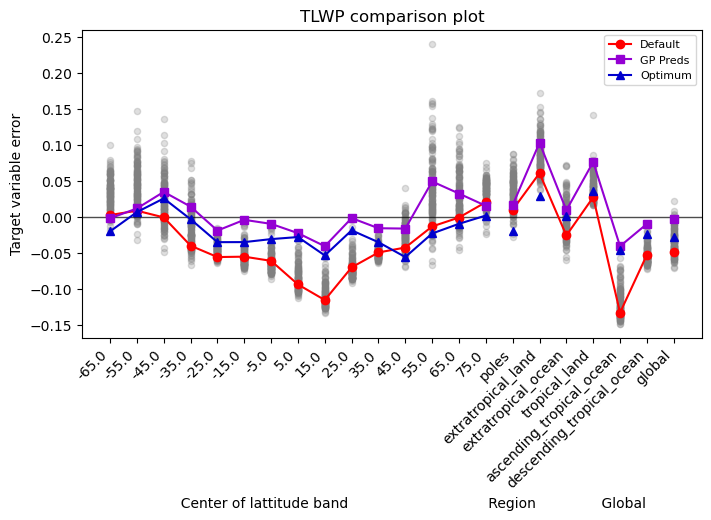

In [192]:
all_num = 22 #25
r_num = 6 #6
z_num = 15 #18
opt_data = PM_DY1_opt_mar26_data_small['TotalLiqWaterPath']
PPE_data = TLWP_train.iloc[:,0:all_num]
obs_data = TLWP_zrg_obs.iloc[:,0:all_num]
opt_preds = TLWP_final_preds[0:all_num]

plt.figure(figsize=(8, 4))
point_size = 30

dict1 = zonal_means_native(opt_data, area, lat, lon)
dict2 = regional_means_native(opt_data, area, regions_file)
array = np.array([global_means_native(opt_data, area)])

# Extract keys and values from dictionaries
keys1, values1 = list(dict1.keys()), list(dict1.values())
keys2, values2 = list(dict2.keys()), list(dict2.values())

keys1 = keys1[2:17]
values1 = values1[2:17]

# Create x positions
x1 = range(len(keys1))  # x positions for dict1
x2 = range(len(keys1), len(keys1) + len(keys2))  # x positions for dict2
x3 = range(len(keys1) + len(keys2), len(keys1) + len(keys2) + len(array))  # x positions for array
array_labels = ['global'] # label for global array

#Scatter each row of zrg ppe dataset
for row_name, row_values in PPE_data.iterrows():
    plt.scatter(range(all_num), (PPE_data.loc[row_name]-obs_data), color='gray', alpha=0.25, s=point_size-10)
    
plt.axhline(y=0, color="black", linewidth=1, zorder=1, alpha=0.7) #linestyle=":",

#plt.scatter(range(all_num), (TLWP_default_values-DY2_TLWP_zrg_obs.iloc[:,0:all_num]), label="Default", marker = '^', color='orange', s=point_size)
plt.plot(x1, (PPE_data.loc['m0000']-obs_data).to_numpy()[0,0:z_num], '-o', color='red')
plt.plot(x2, (PPE_data.loc['m0000']-obs_data).to_numpy()[0,(z_num):(z_num+r_num)], '-o', color='red')
plt.plot(x3, (PPE_data.loc['m0000']-obs_data).to_numpy()[0, -1], '-o', color='red', label="Default")

plt.plot(x1, (opt_preds-obs_data).iloc[0,0:z_num], '-s', color='darkviolet')
plt.plot(x2, (opt_preds-obs_data).iloc[0,(z_num):(z_num+r_num)], '-s', color='darkviolet')
plt.plot(x3, (opt_preds-obs_data).iloc[0, -1], '-s', color='darkviolet', label="GP Preds")

plt.plot(x1, (values1-obs_data.iloc[:,0:z_num]).to_numpy()[0], '-^', label="Optimum", color="mediumblue")
plt.plot(x2, (values2-obs_data.iloc[:,(z_num):(z_num+r_num)]).to_numpy()[0], '^', color="mediumblue")
plt.plot(x3, (array-obs_data.iloc[:,-1]).to_numpy()[0], '-^', color="mediumblue")

# Create combined x-tick labels and positions
all_keys = keys1 + keys2 + array_labels
all_positions = list(x1) + list(x2) + list(x3)

# Customize x-axis
plt.xticks(all_positions, all_keys, rotation=45, ha='right')

plt.xlabel("          Center of lattitude band                                Region               Global")
plt.ylabel("Target variable error")
plt.title("TLWP comparison plot")
plt.legend(fontsize=8)
#plt.tight_layout()
plt.show()

In [199]:
plt.figure(figsize=(8, 4))
point_size = 20

dict1 = zonal_means_native(TLWP_opt, area, lat, lon)
dict2 = regional_means_native(TLWP_opt, area)
array = np.array([global_means_native(TLWP_opt, area)])

# Extract keys and values from dictionaries
keys1, values1 = list(dict1.keys()), list(dict1.values())
keys2, values2 = list(dict2.keys()), list(dict2.values())

# Create x positions
x1 = range(len(keys1))  # x positions for dict1
x2 = range(len(keys1), len(keys1) + len(keys2))  # x positions for dict2
x3 = range(len(keys1) + len(keys2), len(keys1) + len(keys2) + len(array))  # x positions for array
array_labels = ['global'] # label for global array

# Plot scatter points - simulation 
plt.scatter(x1, values1, label="Opt simulation", edgecolor="green", facecolors="none", s=point_size)
plt.scatter(x2, values2, edgecolor="green", facecolors="none", s=point_size)
plt.scatter(x3, array, edgecolor="green", facecolors="none", s=point_size)

plt.scatter(range(len(TLWP_final_preds)), TLWP_final_preds, label="Opt ZRG pred", marker = 's', edgecolors="blue", facecolors="none", s=point_size)
#plt.scatter(range(len(TLWP_final_preds)), TLWP_gridcell, label="Opt gridcell pred", color='purple', s=point_size)
#plt.scatter(range(len(TLWP_final_preds)), TLWP_default_values, label="Default", marker = 'x', color="orange", s=point_size)

plt.scatter(range(len(TLWP_final_preds)), zrg_obs.iloc[:, 25:50], label="Obs", marker = '^', edgecolor='red', facecolors="none", s=point_size)

# Create combined x-tick labels and positions
all_keys = keys1 + keys2 + array_labels
all_positions = list(x1) + list(x2) + list(x3)

# Customize x-axis
plt.xticks(all_positions, all_keys, rotation=45, ha='right')

plt.xlabel("            Center of lattitude band                             Region               Global")
plt.ylabel("Target variable value")
plt.title("TLWP comparison plot")
plt.legend(fontsize=8)
#plt.tight_layout()
plt.show()

NameError: name 'TLWP_opt' is not defined

<Figure size 800x400 with 0 Axes>

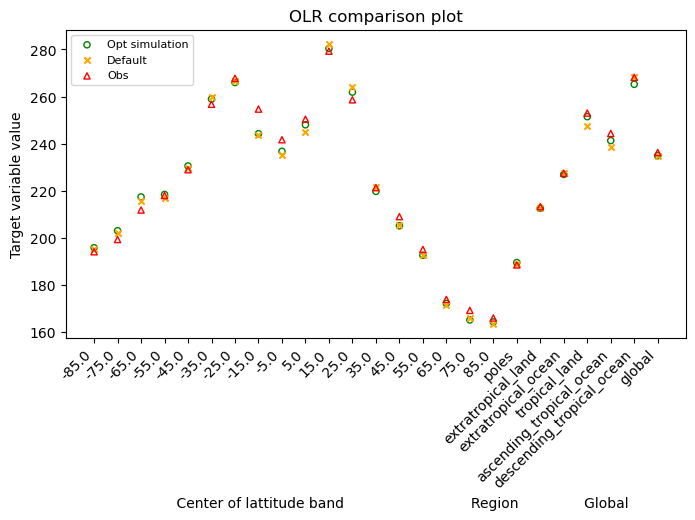

In [194]:
plt.figure(figsize=(8, 4))
point_size = 20

dict1 = zonal_means_native(OLR_opt, area, lat, lon)
dict2 = regional_means_native(OLR_opt, area)
array = np.array([global_means_native(OLR_opt, area)])

# Extract keys and values from dictionaries
keys1, values1 = list(dict1.keys()), list(dict1.values())
keys2, values2 = list(dict2.keys()), list(dict2.values())

# Create x positions
x1 = range(len(keys1))  # x positions for dict1
x2 = range(len(keys1), len(keys1) + len(keys2))  # x positions for dict2
x3 = range(len(keys1) + len(keys2), len(keys1) + len(keys2) + len(array))  # x positions for array
array_labels = ['global'] # label for global array

# Plot scatter points - simulation 
plt.scatter(x1, values1, label="Opt simulation", edgecolor="green", facecolors="none", s=point_size)
plt.scatter(x2, values2, edgecolor="green", facecolors="none", s=point_size)
plt.scatter(x3, array, edgecolor="green", facecolors="none", s=point_size)

#plt.scatter(range(len(OLR_final_preds)), OLR_final_preds, label="Opt ZRG pred", marker = 's', edgecolors="blue", facecolors="none", s=point_size)
#plt.scatter(range(len(OLR_final_preds)), OLR_gridcell, label="Opt gridcell pred", color='purple', s=point_size)
plt.scatter(range(len(OLR_final_preds)), OLR_default_values, label="Default", marker = 'x', color="orange", s=point_size)

plt.scatter(range(len(OLR_final_preds)), zrg_obs.iloc[:, 75:100], label="Obs", marker = '^', edgecolor='red', facecolors="none", s=point_size)

# Create combined x-tick labels and positions
all_keys = keys1 + keys2 + array_labels
all_positions = list(x1) + list(x2) + list(x3)

# Customize x-axis
plt.xticks(all_positions, all_keys, rotation=45, ha='right')

plt.xlabel("            Center of lattitude band                             Region               Global")
plt.ylabel("Target variable value")
plt.title("OLR comparison plot")
plt.legend(fontsize=8)
#plt.tight_layout()
plt.show()

### mappy

In [3]:
X = control.precip_total_surf_mass_flux.values[0]

NameError: name 'control' is not defined

In [1]:
np.random.seed(42)
z = X #np.sin(np.radians(lon)) * np.cos(np.radians(lat))

# Create Basemap
fig, ax = plt.subplots(figsize=(12, 6))
m = Basemap(projection='robin', lon_0=0, resolution='l', ax=ax)

# Transform coordinates to map projection
mx, my = m(lon, lat)

# Create triangulation in projected space
triang = tri.Triangulation(mx, my)

# Mask spurious triangles (long edges from dateline wrapping)
tri_x = mx[triang.triangles]
tri_y = my[triang.triangles]
edge_lengths = np.sqrt(
    np.diff(np.c_[tri_x, tri_x[:, 0:1]], axis=1)**2 +
    np.diff(np.c_[tri_y, tri_y[:, 0:1]], axis=1)**2
)
x_range = mx.max() - mx.min()
mask = edge_lengths.max(axis=1) > 0.05 * x_range
triang.set_mask(mask)

# Plot — use plt.tricontourf, not m.tricontourf
tcf = plt.tricontourf(triang, z, levels=20, cmap='viridis')
m.drawcoastlines()
m.drawcountries(linewidth=0.5)
ax.set_title('Delaunay Triangulation — Basemap')
plt.colorbar(tcf, shrink=0.7)
plt.show()

NameError: name 'X' is not defined